In [1]:
#!pip install lightgbm
#!pip install xgboost
#!pip install catboost
#!pip install imblearn

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer, mean_absolute_percentage_error, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE, ADASYN

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.tree import DecisionTreeClassifier
from statsmodels.tsa.arima.model import ARIMA

from sklearn.multiclass import OneVsRestClassifier

from tqdm import tqdm 

from warnings import filterwarnings 
filterwarnings('ignore')

start_time = time.time()
notebook_start_time = time.time()

## 1. Datasets loading and transformation

In [3]:
# Load the data set
df = pd.read_csv('data/wdic.csv')
df_cpi = pd.read_csv('data/cpi.csv')
df_gdebt = pd.read_csv('data/gdebt.csv')
df_ratings = pd.read_csv('data/countriesratings.csv')
df_wind = pd.read_csv('data/worldeconomicindicators.csv')

In [4]:
# Remove irelevant columns in df
df = df.drop(['Country Code', 'Indicator Code'], axis=1)

In [5]:
# Dropping unwanted columns, merging and renaming columns in df_wind
df_wind = df_wind.drop(['Scale', 'Estimates Start After', '2024', '2025', '2026', '2027', '2028', '2029', '2030'], axis=1)
df_wind['Indicator'] = df_wind['Subject Descriptor'].str.cat(df_wind['Units'], sep='-')
df_wind = df_wind.drop(['Subject Descriptor', 'Units'], axis=1)

### 1.1 Transform datasets and prepare them to be merged into one single dataset

In [6]:
# Transform dataframe with Features as columns and year as one single column

# Step 1: Pivot the 'Indicator' column to create new columns for each indicator
# I use 'Country Name' as the index, 'Indicator Name' as columns, and the years as values.

#====================== Process df ==================================#
years_df = [col for col in df.columns if str(col).isdigit()] # Dynamically get year columns
df_pivot = df.pivot_table(index='Country Name', columns='Indicator Name', values=years_df)


#====================== Process df_cpi ==============================#
years_cpi = [col for col in df_cpi.columns if str(col).isdigit()] # Dynamically get year columns
df_cpi_pivot = df_cpi.pivot_table(index='COUNTRY', columns='INDEX_TYPE', values=years_cpi)


#====================== Process df_gdebt ============================#
years_gdebt = [col for col in df_gdebt.columns if str(col).isdigit()] # Dynamically get year columns
df_gdebt_pivot = df_gdebt.pivot_table(index='COUNTRY', columns='INDICATOR', values=years_gdebt)


#====================== Process df_wind ============================#
# Ensure column names are strings for consistency
df_wind.columns = df_wind.columns.map(lambda x: str(int(x)) if isinstance(x, float) and x.is_integer() else x)

# Identify year columns
years_wind = [col for col in df_wind.columns if str(col).isdigit()]

# Melt to long format
df_wind_long = df_wind.melt(id_vars=['Country', 'Indicator'],
                            value_vars=years_wind,
                            var_name='Year',
                            value_name='Value')
df_wind_long_grouped = (
    df_wind_long
    .groupby(['Country', 'Year', 'Indicator'], as_index=False)
    .agg({'Value': 'first'})  # or 'mean', 'max', etc.
)

# Pivot (MultiIndex: Year, Indicator)
df_wind_pivot = df_wind_long_grouped.pivot(index='Country', columns=['Year', 'Indicator'], values='Value')


In [7]:
# Step 2: Flatten the MultiIndex columns
# This creates new column names like '2021_Population', '2021_GDP', etc.

#====================== Process df ==================================#
df_pivot.columns = [f"{year}_{indicator}" for year, indicator in df_pivot.columns]
df_pivot = df_pivot.reset_index() # Reset index to make 'Country' a regular column

#====================== Process df_cpi ==============================#
df_cpi_pivot.columns = [f"{year}_{indicator}" for year, indicator in df_cpi_pivot.columns]
df_cpi_pivot = df_cpi_pivot.reset_index() # Reset index to make 'Country' a regular column

#====================== Process df_gdebt ============================#
df_gdebt_pivot.columns = [f"{year}_{indicator}" for year, indicator in df_gdebt_pivot.columns]
df_gdebt_pivot = df_gdebt_pivot.reset_index() # Reset index to make 'Country' a regular column

#====================== Process df_wind ============================#
df_wind_pivot.columns = [f"{year}_{indicator}" for year, indicator in df_wind_pivot.columns]
df_wind_pivot = df_wind_pivot.reset_index() # Reset index to make 'Country' a regular column

In [8]:
# Step 3: Melt the year-indicator columns into 'Year' and individual indicator columns
# I use 'Country Name' as id_vars (identifier variables).
# I want to create a 'Year' column and columns for 'Population', 'GDP', 'Inflation', etc..
# First, I prepare for melting by creating a combined 'Year_Indicator' column
# Then, I want to melt the year-specific columns back into a single 'Year' column.
# The `id_vars` will be 'Country Name'.
# The `value_vars` will be all the new columns that combine year and indicator.
# Dynamically I get the columns that combine year and indicator (e.g., '2021_Population')

#====================== Process df ==================================#
melt_value_vars = [col for col in df_pivot.columns if '_' in col] # Simple way to get them after flattening

df_final = pd.melt(df_pivot,
                   id_vars=['Country Name'],
                   value_vars=melt_value_vars,
                   var_name='Year_Indicator', # This temporary column will hold '2021_Population' etc.
                   value_name='Value')

# Separate 'Year' and 'Indicator' from 'Year_Indicator'
df_final[['Year', 'Indicator']] = df_final['Year_Indicator'].str.split('_', expand=True)

# Pivot to get 'Population', 'GDP', 'Inflation' as columns
df_final = df_final.pivot_table(index=['Country Name', 'Year'],
                                columns='Indicator',
                                values='Value',
                                aggfunc='first').reset_index() # Use aggfunc='first' as there's only one value per combination

# Clean up column names
df_final.columns.name = None

#====================== Process df_cpi ==============================#
melt_value_vars_df_cpi = [col for col in df_cpi_pivot.columns if '_' in col] # Simple way to get them after flattening

df_cpi_final = pd.melt(df_cpi_pivot,
                   id_vars=['COUNTRY'],
                   value_vars=melt_value_vars_df_cpi,
                   var_name='Year_Indicator', # This temporary column will hold '2021_Population' etc.
                   value_name='Value')

# Separate 'Year' and 'Indicator' from 'Year_Indicator'
df_cpi_final[['Year', 'Indicator']] = df_cpi_final['Year_Indicator'].str.split('_', expand=True)

# Pivot to get 'Population', 'GDP', 'Inflation' as columns
df_cpi_final = df_cpi_final.pivot_table(index=['COUNTRY', 'Year'],
                                columns='Indicator',
                                values='Value',
                                aggfunc='first').reset_index() # I use aggfunc='first' as there's only one value per combination

# Clean up column names
df_cpi_final.columns.name = None

#====================== Process df_gdebt ============================#
melt_value_vars_df_gdebt = [col for col in df_gdebt_pivot.columns if '_' in col] # Simple way to get them after flattening

df_gdebt_final = pd.melt(df_gdebt_pivot,
                   id_vars=['COUNTRY'],
                   value_vars=melt_value_vars_df_gdebt,
                   var_name='Year_Indicator', # This temporary column will hold '2021_Population' etc.
                   value_name='Value')

# Separate 'Year' and 'Indicator' from 'Year_Indicator'
df_gdebt_final[['Year', 'Indicator']] = df_gdebt_final['Year_Indicator'].str.split('_', expand=True)

# Pivot to get 'Population', 'GDP', 'Inflation' as columns
df_gdebt_final = df_gdebt_final.pivot_table(index=['COUNTRY', 'Year'],
                                columns='Indicator',
                                values='Value',
                                aggfunc='first').reset_index() # I use aggfunc='first' as there's only one value per combination

# Clean up column names 
df_gdebt_final.columns.name = None

#====================== Process df_wind ============================#
melt_value_vars_df_wind = [col for col in df_wind_pivot.columns if '_' in col] # Simple way to get them after flattening

df_wind_final = pd.melt(df_wind_pivot,
                   id_vars=['Country'],
                   value_vars=melt_value_vars_df_wind,
                   var_name='Year_Indicator', # This temporary column will hold '2021_Population' etc.
                   value_name='Value')

# Separate 'Year' and 'Indicator' from 'Year_Indicator'
df_wind_final[['Year', 'Indicator']] = df_wind_final['Year_Indicator'].str.split('_', expand=True)

# Pivot to get 'Population', 'GDP', 'Inflation' as columns
df_wind_final = df_wind_final.pivot_table(index=['Country', 'Year'],
                                columns='Indicator',
                                values='Value',
                                aggfunc='first').reset_index() # I use aggfunc='first' as there's only one value per combination

# Cleaning up column names
df_wind_final.columns.name = None

### 1.2 Clean duplicates, change datatypes, standardize names and transform columns

In [9]:
# Process ratings data frame and prepare it for merge
# Select only the latest rating for each year by sorting date and selecting the latest row (closest to month of december)
df_ratings['Date'] = pd.to_datetime(df_ratings['Date'])
df_sorted = df_ratings.sort_values(by='Date')
df_latest = (
    df_sorted
    .groupby(['Country', 'Year'], as_index=False)
    .tail(1)
    .sort_values(by=['Country', 'Year', 'Date'])
    .reset_index(drop=True)
)
df_ratings_final = df_latest.copy()

In [10]:
# Checking and processing duplicates if necesary
print("="*50)
print(f"Total number of duplicates for df:", df_final.duplicated().sum())
print(f"Total number of duplicates for df_cpi:", df_cpi_final.duplicated().sum())
print(f"Total number of duplicates for df_gdebt:", df_gdebt_final.duplicated().sum())
print(f"Total number of duplicates for df_ratings:", df_ratings_final.duplicated().sum())
print(f"Total number of duplicates for df_wind:", df_wind_final.duplicated().sum())
print("="*50)

Total number of duplicates for df: 0
Total number of duplicates for df_cpi: 0
Total number of duplicates for df_gdebt: 0
Total number of duplicates for df_ratings: 0
Total number of duplicates for df_wind: 0


In [11]:
# Standardize column names to lower case and change data types where applicable

# Change to lower case all column names for all dataframes
df_final.columns = [col.lower() for col in df_final.columns]
df_cpi_final.columns = [col.lower() for col in df_cpi_final.columns]
df_gdebt_final.columns = [col.lower() for col in df_gdebt_final.columns]
df_ratings_final.columns = [col.lower() for col in df_ratings_final.columns]
df_wind_final.columns = [col.lower() for col in df_wind_final.columns]

# Convert year columns in Datetime data type for all dataframes
df_final['year'] = pd.to_datetime(df_final['year'], errors='coerce').dt.year
df_cpi_final['year'] = pd.to_datetime(df_cpi_final['year'], errors='coerce').dt.year
df_gdebt_final['year'] = pd.to_datetime(df_gdebt_final['year'], errors='coerce').dt.year
df_wind_final['year'] = pd.to_datetime(df_wind_final['year'], errors='coerce').dt.year

# Rename df country name to country in preparation of the final merge
df_final.rename(columns={'country name': 'country'}, inplace=True)

# Convert data types in df
# Define the string patterns that, if present in the column name, should prevent conversion to Int64 (I will keep them as float64)
patterns_to_exclude = ['%', 'percent', 'standard error', 'estimate', 'period average', 'index'] # Patterns to exclude from conversion

# Identify columns to  convert
columns_to_check = []
for col in df_final.columns:
    
    # Check if the column is float64
    if df_final[col].dtype == 'float64':
    
        # Check if any of the exclusion patterns are NOT in the column name
        # Convert if the column name DOES NOT contain any of the exclusion patterns
        should_convert = True
        for pattern in patterns_to_exclude:
            if pattern in col.lower(): # Case-insensitive check
                should_convert = False
                break # Found an exclusion pattern, no need to check further
        if should_convert:
            columns_to_check.append(col)

print("="*112)
print(f"\nColumns identified for conversion to Int64: {columns_to_check}")

# Perform the conversion with rounding for problematic columns
for col in columns_to_check:
    # Check if the column contains any non-integer values
    # Exclude NaNs from this check as Int64 can handle them.
    # I check if after dropping NaNs, any value is not equal to its integer cast.
    has_fractional_parts = ((df_final[col].dropna() % 1) != 0).any()

    if has_fractional_parts:
        print(f"Warning: Column '{col}' contains fractional parts. Rounding before converting.")
        # Round to the nearest integer. .round() handles NaNs
        df_final[col] = df_final[col].round().astype('Int64')
    else:
        # If no fractional parts, or only NaNs, direct cast should work.
        df_final[col] = df_final[col].astype('Int64')
    print(f"Converted '{col}' to Int64.")
    
print("="*112)


Columns identified for conversion to Int64: ['central government debt, total (current lcu)', 'compulsory education, duration (years)', 'current account balance (bop, current us$)', 'current health expenditure per capita, ppp (current international $)', 'goods exports (bop, current us$)', 'goods imports (bop, current us$)']
Converted 'central government debt, total (current lcu)' to Int64.
Converted 'compulsory education, duration (years)' to Int64.
Converted 'current account balance (bop, current us$)' to Int64.
Converted 'current health expenditure per capita, ppp (current international $)' to Int64.
Converted 'goods exports (bop, current us$)' to Int64.
Converted 'goods imports (bop, current us$)' to Int64.


In [12]:
#List of countries that do not exist in df_final but exists in df_ratings_final
countries_not_in_df_final = df_ratings_final[~df_ratings_final['country'].isin(df_final['country'])]['country'].unique().tolist()
print("="*112)
print("Countries from df_ratings_final not in df_final:\n", countries_not_in_df_final)
print("="*112)

#List of countries that do not exist is df_final but exists in df_cpi_final
countries_not_in_df_final = df_cpi_final[~df_cpi_final['country'].isin(df_final['country'])]['country'].unique().tolist()
print("="*112)
print("Countries from df_cpi_final not in df_final:\n", countries_not_in_df_final)
print("="*112)

#List of countries that do not exist is df_final but exists in df_gdebt_final
countries_not_in_df_final = df_gdebt_final[~df_gdebt_final['country'].isin(df_final['country'])]['country'].unique().tolist()
print("="*112)
print("Countries from df_gdebt_final not in df_final:\n", countries_not_in_df_final)
print("="*112)

#List of countries that do not exist is df_final but exists in df_gdebt_final
countries_not_in_df_final = df_wind_final[~df_wind_final['country'].isin(df_final['country'])]['country'].unique().tolist()
print("="*112)
print("Countries from df_gdebt_final not in df_final:\n", countries_not_in_df_final)
print("="*112)

Countries from df_ratings_final not in df_final:
 ['Congo', 'Cook Islands', "Cote d'Ivoire", "C\x81Ete d'Ivoire", 'Egypt', 'Falkland Islands', 'Guernsey', 'Jersey', 'Macao', 'Montserrat', 'Republic of the Congo', 'Saint Helena', 'Solomon Island', 'St Vincent and The Grenadines', 'Swaziland', 'Taiwan']
Countries from df_cpi_final not in df_final:
 ['Anguilla, United Kingdom-British Overseas Territory', "Côte d'Ivoire", 'Guadeloupe', 'Martinique', 'Montserrat, United Kingdom-British Overseas Territory']
Countries from df_gdebt_final not in df_final:
 ["Côte d'Ivoire", 'Taiwan Province of China']
Countries from df_gdebt_final not in df_final:
 ["Cote d'Ivoire", 'S\x81EEEo Tom\x81EEE and Pr\x81EEEncipe', 'Taiwan Province of China']


### 1.3 Merge datasets into final dataset

In [13]:
# Merge all Data Frames in one single Data Frame in two stages
merged_df_1 = pd.merge(df_final, df_cpi_final, on=['country', 'year'], how='left')
merged_df_2 = pd.merge(merged_df_1, df_gdebt_final, on=['country', 'year'], how='left')
merged_df_3 = pd.merge(merged_df_2, df_wind_final, on=['country', 'year'], how='left')
final_merged_df = pd.merge(merged_df_3, df_ratings_final, on=['country', 'year'], how='left')

#Convert data type for ratings columns
final_merged_df[['ratingn']] = final_merged_df[['ratingn']].round().astype('Int64')
df_final = final_merged_df.copy()

In [14]:
# Standardize all column names
df_final.columns = df_final.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
print(df_final.columns)

Index(['country', 'year', 'bank_capital_to_assets_ratio_(%)',
       'bank_nonperforming_loans_to_total_gross_loans_(%)',
       'central_government_debt,_total_(%_of_gdp)',
       'central_government_debt,_total_(current_lcu)',
       'compulsory_education,_duration_(years)',
       'control_of_corruption:_estimate',
       'control_of_corruption:_standard_error',
       'current_account_balance_(%_of_gdp)',
       ...
       'unemployment_rate_percent_of_total_labor_force',
       'volume_of_imports_of_goods_percent_change',
       'volume_of_exports_of_goods_and_services_percent_change',
       'volume_of_exports_of_goods_percent_change',
       'volume_of_imports_of_goods_and_services_percent_change', 'agency',
       'rating', 'ratingn', 'outlook', 'date'],
      dtype='object', length=103)


In [15]:
# Convert rest of the object datatypes to numerical datatypes

# List the columns you want to exclude from conversion
exclude_cols = ['country', 'outlook', 'rating', 'agency']

# Loop through all object columns, but only run the code for columns not in the exclude list
for col in df_final.select_dtypes(include=['object']).columns:
    if col not in exclude_cols:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

In [16]:
# Convert date column in Datetime data type
df_final['date'] = pd.to_datetime(df_final['date'], errors='coerce')
df_final['date'] = df_final['date'].dt.normalize()

## 2. Exploratory Data Analysis (EDA)

### 2.1 Data Cleaning

#### 2.1.1 Cleaning non-country entities

In [17]:
# Cleaning values and categories that should not be part of the data set
# Check the list of countries and remove non-countries entities
#df_final['country'].unique().tolist()

# Remove entities that are not countries
entities_to_remove = ['Africa Eastern and Southern', 'Africa Western and Central', 'American Samoa', 'Arab World', 'Bermuda', 'Caribbean small states', 'Central Europe and the Baltics', 
                     'Early-demographic dividend', 'East Asia & Pacific', 'East Asia & Pacific (IDA & IBRD countries)', 'East Asia & Pacific (excluding high income)',
                     'Euro area', 'Europe & Central Asia', 'Europe & Central Asia (IDA & IBRD countries)', 'Europe & Central Asia (excluding high income)', 'European Union',
                     'Faroe Islands', 'Fragile and conflict affected situations', 'Heavily indebted poor countries (HIPC)', 'High income', 'IBRD only',
                     'IDA & IBRD total', 'IDA blend', 'IDA only', 'IDA total', 'Late-demographic dividend', 'Latin America & Caribbean', 'Latin America & Caribbean (excluding high income)',
                     'Latin America & the Caribbean (IDA & IBRD countries)', 'Least developed countries: UN classification', 'Low & middle income', 'Low income',
                     'Lower middle income', 'Middle East & North Africa', 'Middle East & North Africa (IDA & IBRD countries)', 'Middle East & North Africa (excluding high income)',
                     'Middle income', 'North America', 'OECD members', 'Other small states', 'Pacific island small states', 'Post-demographic dividend', 'Pre-demographic dividend',
                     'Small states', 'South Asia', 'South Asia (IDA & IBRD)', 'Sub-Saharan Africa', 'Sub-Saharan Africa (IDA & IBRD countries)', 'Sub-Saharan Africa (excluding high income)',
                     'Upper middle income',  'World']

df_filtered1 = df_final[~df_final['country'].isin(entities_to_remove)]
df_final = df_filtered1

print("="*50)
print(f'Total number of countries: {len(df_final["country"].unique())}')
print("="*50)

Total number of countries: 214


#### 2.1.2 Cleaning years that have the most missing values

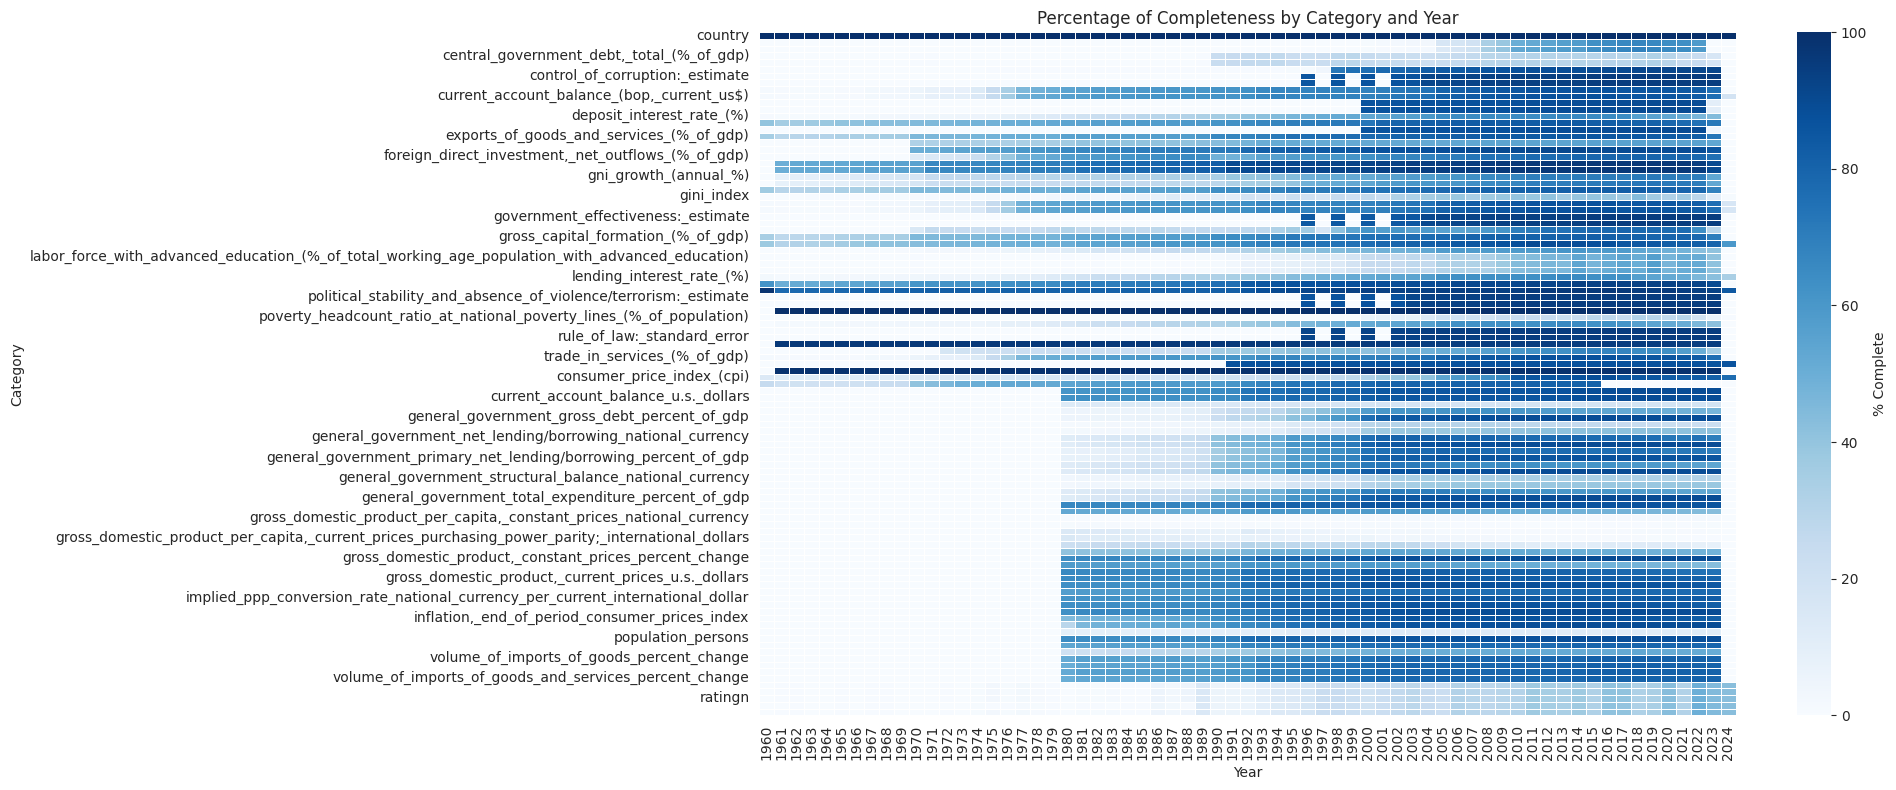

In [18]:
# Check % data completeness per category for all years to decide the period to be removed from data set
rows_per_year = df_final.groupby('year').size()
non_missing_by_year = df_final.groupby('year').count()
percent_complete = (non_missing_by_year.T / rows_per_year).T * 100
percent_complete = percent_complete.apply(pd.to_numeric, errors='coerce')

#Setting plot style
sns.set_style("whitegrid")

plt.figure(figsize=(20, 8))
sns.heatmap(percent_complete.T, cmap="Blues", annot=False, fmt=".1f", linewidths=0.5, cbar_kws={'label': '% Complete'})
plt.title('Percentage of Completeness by Category and Year')
plt.xlabel('Year')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [19]:
# Before year 1980 and for the year 2024 (recent data is not available yet) data is very scarce and we should remove it.
# Filter data only for years between 1980-2023
df_filtered = df_final[df_final['year'].between(1980, 2023)]
df_final = df_filtered.copy()

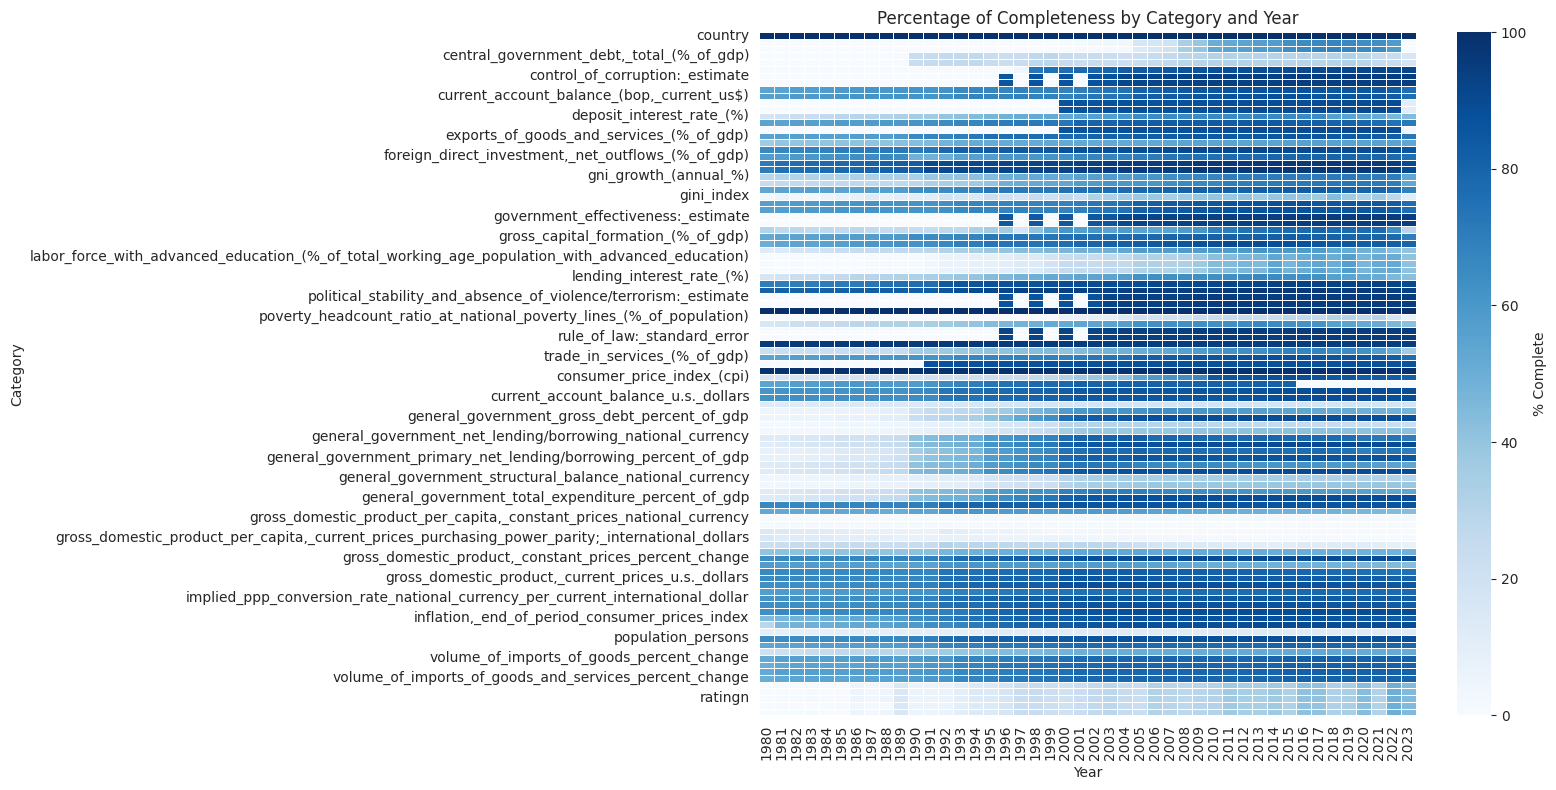

In [20]:
#Check new distribution
rows_per_year = df_final.groupby('year').size()
non_missing_by_year = df_final.groupby('year').count()
percent_complete = (non_missing_by_year.T / rows_per_year).T * 100
percent_complete = percent_complete.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(16, 8))
sns.heatmap(percent_complete.T, cmap="Blues", annot=False, fmt=".1f", linewidths=0.5, cbar_kws={'label': '% Complete'})
plt.title('Percentage of Completeness by Category and Year')
plt.xlabel('Year')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

#### 2.1.3 Cleaning countries that have the most missing values

#### 2.1.4 Cleaning Countries with no ratings or many missing values

In [21]:
# Define target columns to check
target_cols = ['ratingn']

# Calculate missingness percentage per country for those columns
missing_by_country = (
    df_final
    .groupby('country')[target_cols]
    .apply(lambda x: x.isna().mean() * 100)
)

# Rule 1: Countries where ANY of the target columns has 90% missing values
countries_missing_too_much = (
    missing_by_country[missing_by_country.max(axis=1) > 90]
    .index
    .tolist()
)

# Rule 2: Countries with fewer than 3 valid (non-missing) values in ratingn
ratingn_counts = df_final.groupby('country')['ratingn'].count()
countries_with_few_ratingn = ratingn_counts[ratingn_counts < 2].index.tolist()

# Combine both rules
countries_to_remove = list(set(countries_missing_too_much + countries_with_few_ratingn))

# Display results
print("="*50)
print("Countries flagged for removal:")
print("="*50)
print(countries_to_remove)
print("="*50)


Countries flagged for removal:
['Zimbabwe', 'Guam', 'Comoros', 'Nepal', 'Bangladesh', 'Maldives', 'Liberia', 'Chad', 'Timor-Leste', 'St. Vincent and the Grenadines', 'Guinea', 'Vanuatu', 'Sao Tome and Principe', 'Central African Republic', 'New Caledonia', 'Tanzania', 'Gibraltar', 'Channel Islands', 'Kosovo', 'Lesotho', 'Sint Maarten (Dutch part)', 'Madagascar', 'Grenada', 'Haiti', 'Greenland', 'Marshall Islands', 'Iran, Islamic Rep.', 'United States', 'Puerto Rico', 'Antigua and Barbuda', 'St. Martin (French part)', 'Eswatini', 'Palau', 'Brunei Darussalam', 'Malawi', 'Djibouti', 'Nauru', 'Myanmar', 'Algeria', 'Equatorial Guinea', 'Virgin Islands (U.S.)', 'Mauritania', 'Kyrgyzstan', 'Solomon Islands', 'Tonga', 'Liechtenstein', 'Libya', 'French Polynesia', 'Northern Mariana Islands', 'Somalia', 'Laos', 'Kiribati', 'Guinea-Bissau', 'Yemen, Rep.', 'Sierra Leone', 'Bhutan', 'San Marino', 'Syrian Arab Republic', 'Turks and Caicos Islands', 'Niger', 'Togo', 'Gambia, The', 'Curacao', 'Burundi

In [22]:
# Filter df_final to keep only those countries that have ratings
df_filtered = df_final[~df_final['country'].isin(countries_to_remove)]

df_final = df_filtered.copy()

print('LIST OF REMOVED COUNTRIES')
print("="*112)
print(countries_to_remove)
print("="*112)
print("="*50)
print(f' Total number of countries left: {len(df_final["country"].unique())}')
print("="*50)

LIST OF REMOVED COUNTRIES
['Zimbabwe', 'Guam', 'Comoros', 'Nepal', 'Bangladesh', 'Maldives', 'Liberia', 'Chad', 'Timor-Leste', 'St. Vincent and the Grenadines', 'Guinea', 'Vanuatu', 'Sao Tome and Principe', 'Central African Republic', 'New Caledonia', 'Tanzania', 'Gibraltar', 'Channel Islands', 'Kosovo', 'Lesotho', 'Sint Maarten (Dutch part)', 'Madagascar', 'Grenada', 'Haiti', 'Greenland', 'Marshall Islands', 'Iran, Islamic Rep.', 'United States', 'Puerto Rico', 'Antigua and Barbuda', 'St. Martin (French part)', 'Eswatini', 'Palau', 'Brunei Darussalam', 'Malawi', 'Djibouti', 'Nauru', 'Myanmar', 'Algeria', 'Equatorial Guinea', 'Virgin Islands (U.S.)', 'Mauritania', 'Kyrgyzstan', 'Solomon Islands', 'Tonga', 'Liechtenstein', 'Libya', 'French Polynesia', 'Northern Mariana Islands', 'Somalia', 'Laos', 'Kiribati', 'Guinea-Bissau', 'Yemen, Rep.', 'Sierra Leone', 'Bhutan', 'San Marino', 'Syrian Arab Republic', 'Turks and Caicos Islands', 'Niger', 'Togo', 'Gambia, The', 'Curacao', 'Burundi', 'W

In [23]:
# Cheching for countries with missing years
expected_years = set(range(df_final['year'].min(), df_final['year'].max() + 1))

missing_years = {}

for country, group in df_final.groupby('country'):
    actual_years = set(group['year'].unique())
    missing = expected_years - actual_years
    if missing:  # store only if missing
        missing_years[country] = sorted(missing)

print("="*50)
print("Countries with missing years:", len(missing_years))
for c, yrs in list(missing_years.items())[:100]:  # preview first 5
    print(f"{c}: missing {yrs}")
print("="*50)

Countries with missing years: 0


#### 2.1.5 Cleaning categories that are are not needed or/and have too many missing values

In [24]:
# Check categories with 70% or more missing data
df_cat_to_remove = df_final.isna().mean().multiply(100).round(2).sort_values(ascending=False)

# Filter for categories with >= 70% missing values
df_cat_to_remove = df_cat_to_remove[df_cat_to_remove >= 70]

print('======== CATEGORIES WITH >= 70% MISSING DATA ========')
print("="*75)
print(df_cat_to_remove)
print("="*75)

======== CATEGORIES WITH >= 70% MISSING DATA ========
gross_domestic_product_per_capita,_constant_prices_national_currency                                     99.25
gross_domestic_product_per_capita,_constant_prices_purchasing_power_parity;_2021_international_dollar    99.00
gross_domestic_product_per_capita,_current_prices_purchasing_power_parity;_international_dollars         96.95
gross_domestic_product_per_capita,_current_prices_national_currency                                      94.33
gross_domestic_product_per_capita,_current_prices_u.s._dollars                                           86.29
poverty_headcount_ratio_at_national_poverty_lines_(%_of_population)                                      83.38
output_gap_in_percent_of_potential_gdp_percent_of_potential_gdp                                          80.98
general_government_net_debt_national_currency                                                            73.55
employment_persons                                        

In [25]:
# Removing categories with more than 70% missing values
df_cat_to_remove = df_cat_to_remove.index.tolist()
df_filtered = df_final.drop(columns=df_cat_to_remove)
df_final = df_filtered.copy()

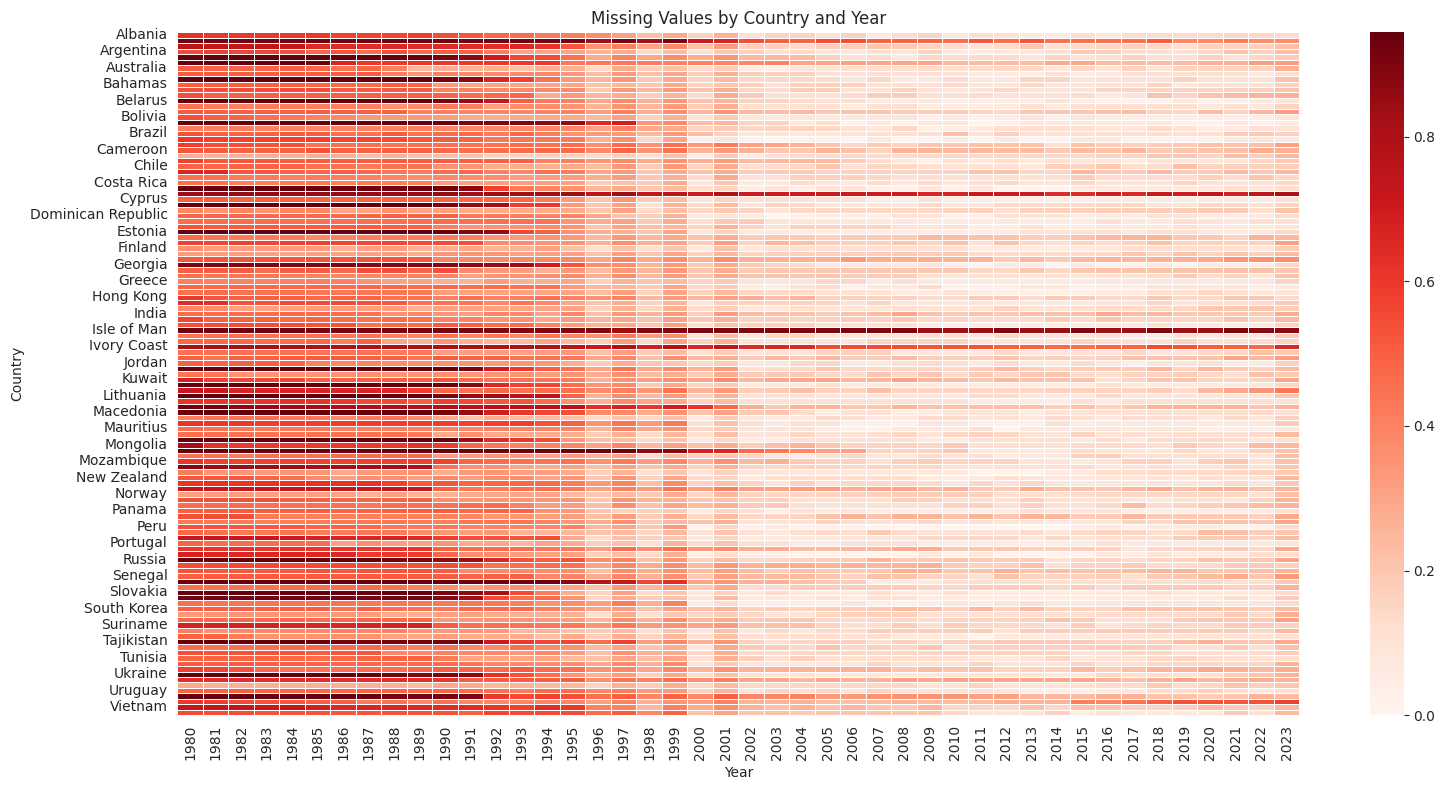

In [26]:
# Check for the missing data using a heatmap
df_final['missing_count'] = df_final.isna().mean(axis=1)
missing_by_country_year = df_final.groupby(['year', 'country'])['missing_count'].sum().reset_index()

heatmap_data = missing_by_country_year.pivot(index='country', columns='year', values='missing_count')

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap='Reds', annot=False, fmt='.0f', linewidths=0.5)
plt.title('Missing Values by Country and Year')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# Drop the missing_count column
df_final.drop(columns='missing_count', inplace=True)

#### 2.1.6 Checking correlations and multicollinearity - Stage I (pre-imputation)

In [27]:
# Calculate the percentage of missing values for each feature

# Define the columns to exclude from the correlation and multicolinearity check
excluded_cols = ['ratingn', 'country', 'year', 
                 'government_effectiveness:_estimate'
                ]

# Create a list of columns that will be included in the correlation check
numerical_cols_to_check = [col for col in df_final.columns if df_final[col].dtype in ['int64', 'float64'] and col not in excluded_cols]

# Create a temporary DataFrame for the correlation check
df_temp = df_final[numerical_cols_to_check]

# Calculate the correlation matrix
corr_matrix = df_temp.corr()

# Create a boolean mask for correlations above the threshold (I have chosen 0.7 as threeshold)
high_corr_mask = (corr_matrix.abs() > 0.8) & (corr_matrix.abs() < 1.0)

# Unstack the matrix to get a list of all highly correlated pairs
high_corr_pairs = high_corr_mask.unstack()

# Filter for the pairs that are True
filtered_multicollinear_features = high_corr_pairs[high_corr_pairs].index.tolist()

missing_values_percent = df_temp.isnull().mean()

# Identify features to drop based on the missing values rule
features_to_drop = set()
checked_pairs = set()

print("=" * 150)
print("Analyzing Multicollinear Pairs for Missing Values:")
print("-" * 50)

for pair in filtered_multicollinear_features:
    # Ensure the pair hasn't been processed in a different order
    if tuple(sorted(pair)) in checked_pairs:
        continue
    
    # Get the missing value percentage for each feature in the pair
    feat1, feat2 = pair
    mv1 = missing_values_percent[feat1]
    mv2 = missing_values_percent[feat2]
    
    # Apply the rule: keep the feature with fewer missing values
    if mv1 > mv2:
        features_to_drop.add(feat1)
        print(f"Pair: ({feat1}, vs. {feat2}) | Missing Values: {mv1:.2%} vs {mv2:.2%}")
        print(f"-> Discarding '{feat1}'")
    elif mv2 > mv1:
        features_to_drop.add(feat2)
        print(f"Pair: ({feat1}, vs. {feat2}) | Missing Values: {mv1:.2%} vs {mv2:.2%}")
        print(f"-> Discarding '{feat2}'")
    else:
        # If missing values are equal, I will keep the one that comes first in the list
        print(f"Pair: ({feat1},  vs. {feat2}) | Missing Values are equal ({mv1:.2%})")
        
    checked_pairs.add(tuple(sorted(pair)))

print("=" * 112)
print("Final list of features to discard due to high multicollinearity and high missing values:")
print("=" * 112)
print(list(features_to_drop))
print("=" * 112)

Analyzing Multicollinear Pairs for Missing Values:
--------------------------------------------------
Pair: (control_of_corruption:_estimate,  vs. rule_of_law:_estimate) | Missing Values are equal (43.75%)
Pair: (control_of_corruption:_standard_error,  vs. rule_of_law:_standard_error) | Missing Values are equal (43.75%)
Pair: (current_account_balance_(%_of_gdp), vs. current_account_balance_percent_of_gdp) | Missing Values: 17.58% vs 11.07%
-> Discarding 'current_account_balance_(%_of_gdp)'
Pair: (current_health_expenditure_(%_of_gdp), vs. domestic_general_government_health_expenditure_(%_of_gdp)) | Missing Values: 49.56% vs 49.80%
-> Discarding 'domestic_general_government_health_expenditure_(%_of_gdp)'
Pair: (deposit_interest_rate_(%), vs. interest_rate_spread_(lending_rate_minus_deposit_rate,_%)) | Missing Values: 45.71% vs 52.25%
-> Discarding 'interest_rate_spread_(lending_rate_minus_deposit_rate,_%)'
Pair: (deposit_interest_rate_(%), vs. lending_interest_rate_(%)) | Missing Values

#### 2.1.7 Drop unwanted columns

In [28]:
df_final.drop(columns=features_to_drop, inplace=True)

In [29]:
# Drop columns that are not relevant or shows multicolinearity
columns_to_drop = [
    'agency', 'rating', 'date',
    'government_effectiveness:_standard_error',
    'rule_of_law:_standard_error',
    'control_of_corruption:_standard_error',
    'political_stability_and_absence_of_violence/terrorism:_standard_error',
    'rule_of_law:_standard_error'
    ]

# Drop the columns
df_final.drop(columns=columns_to_drop, inplace=True)

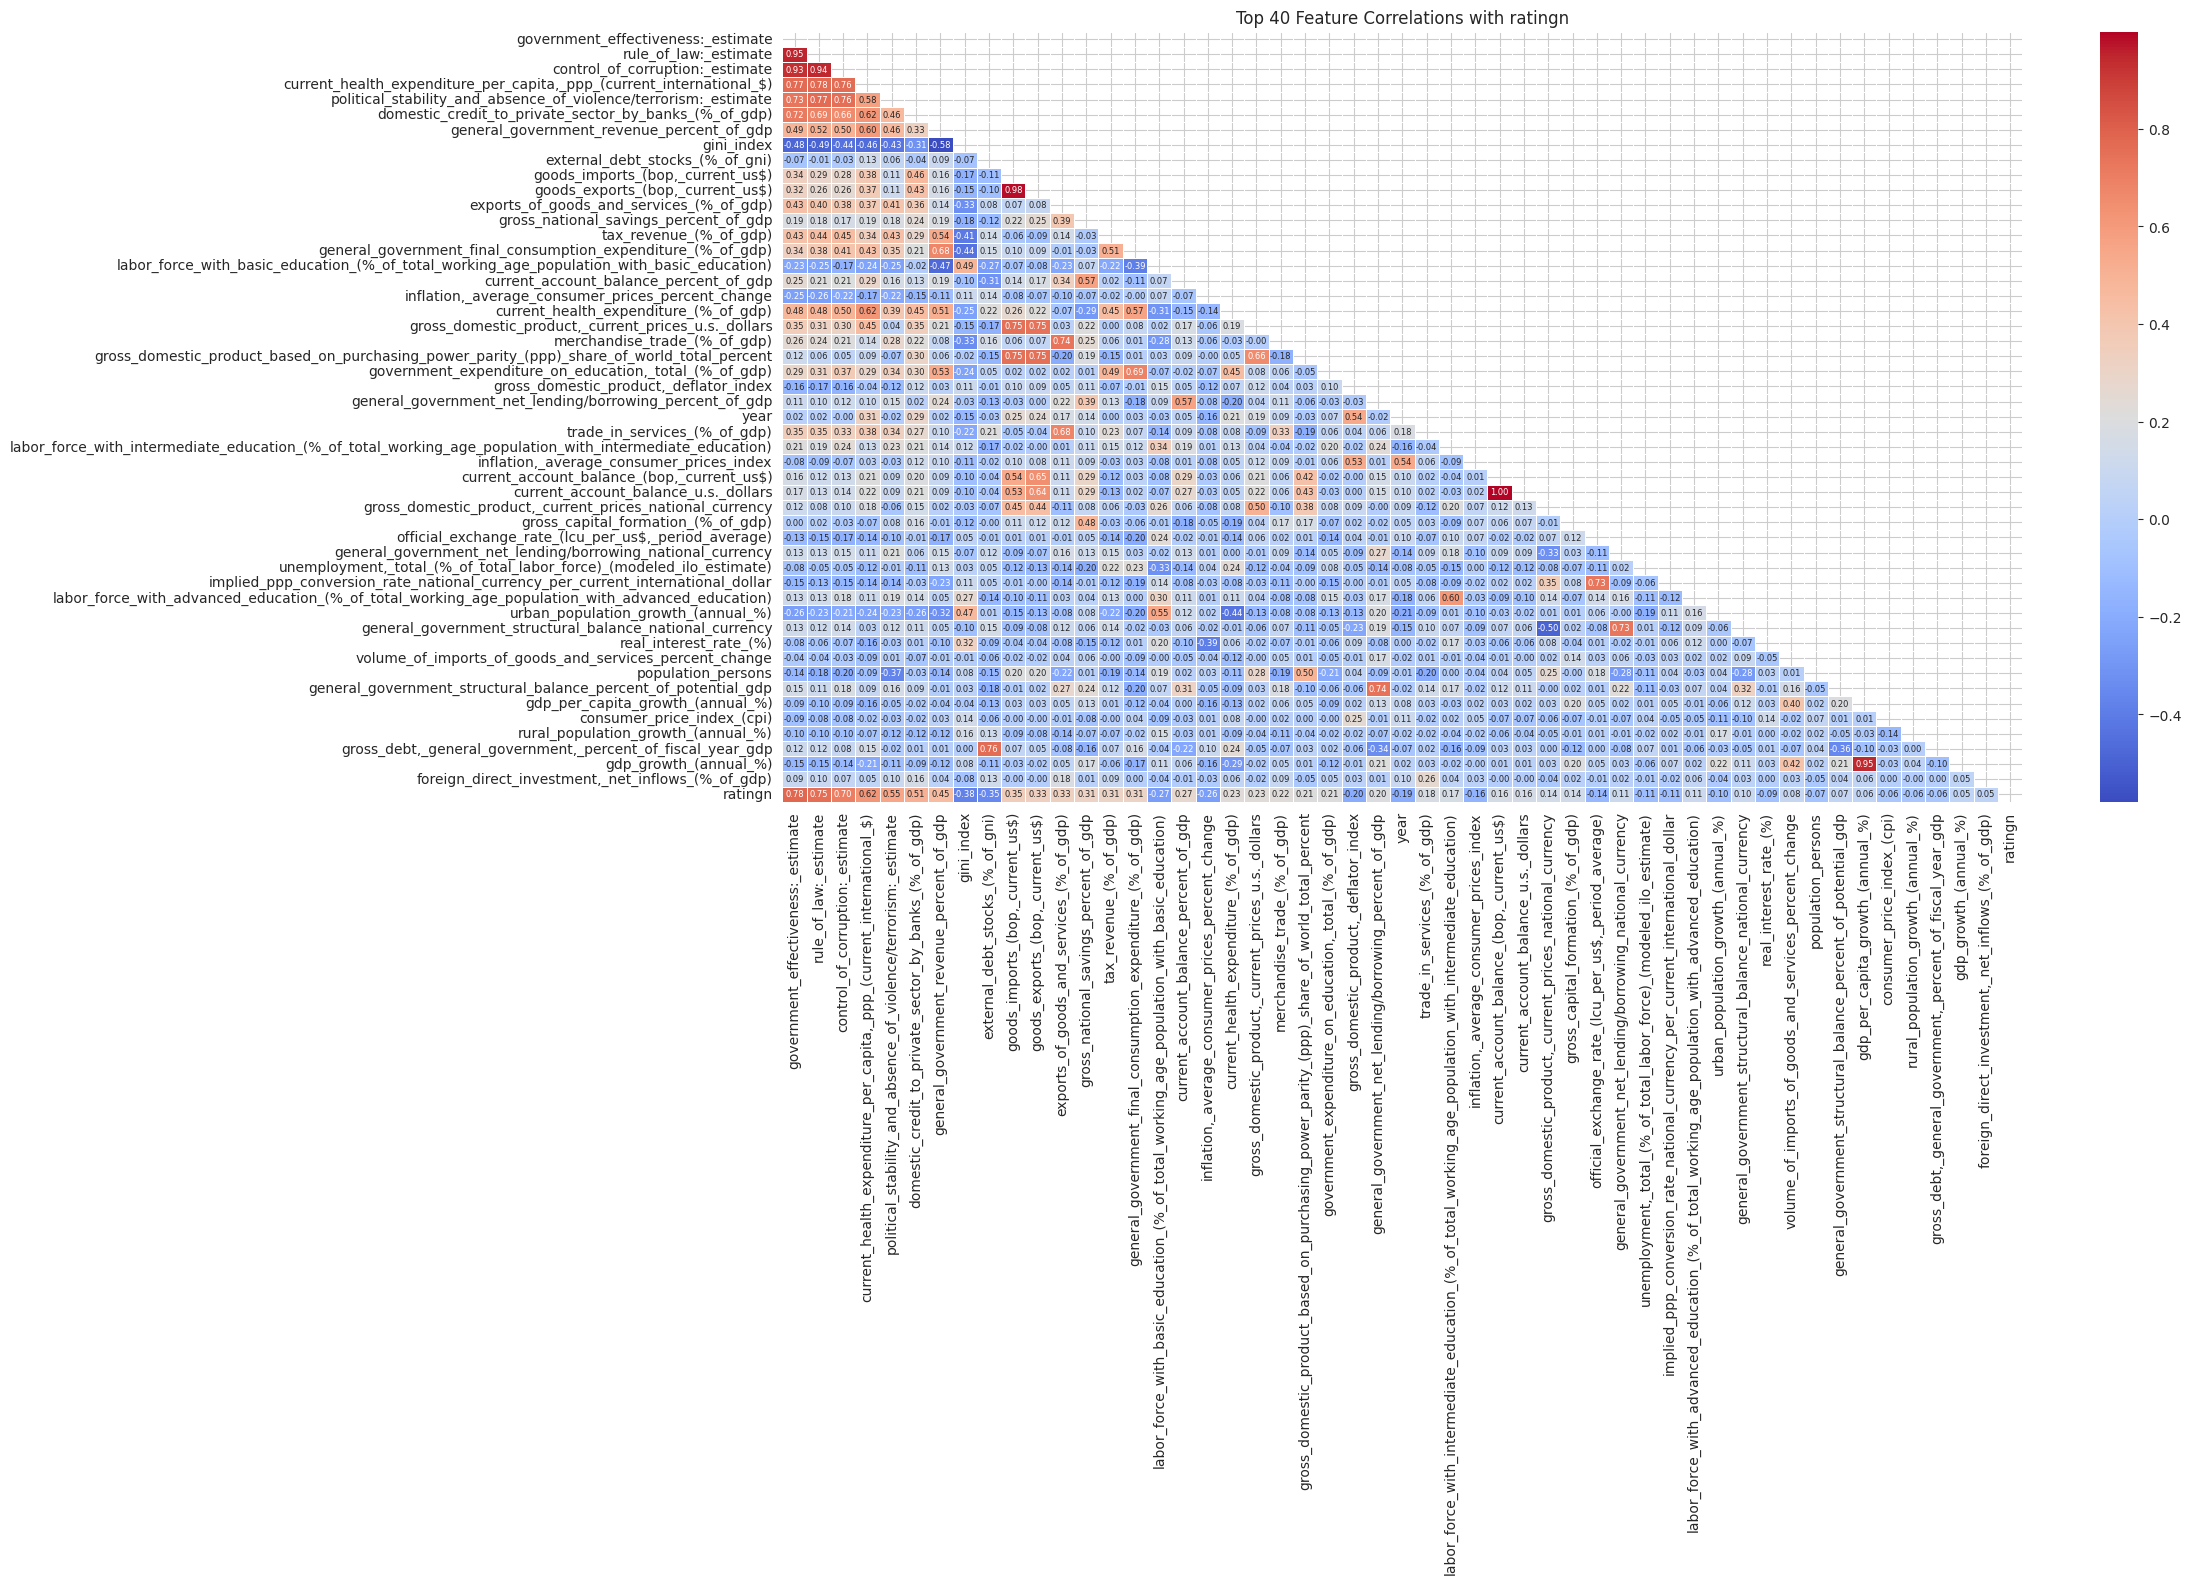

In [30]:
# Checking corelation with 'ratingn' for the top features
corr_matrix = df_final.corr(numeric_only=True)
target_corr = corr_matrix['ratingn'].abs().sort_values(ascending=False)

# Select the top 40 most correlated features to focus on
top_features = target_corr[1:51].index.tolist()

# Create a new DataFrame with only these features plus the target
df_subset = df_final[top_features + ['ratingn']]

# Plot the heatmap for the subset
plt.figure(figsize=(20, 10))
mask = np.triu(np.ones_like(df_subset.corr(), dtype=bool))
sns.heatmap(df_subset.corr(numeric_only=True), mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 6})
plt.title('Top 40 Feature Correlations with ratingn')
plt.show()

#### 2.1.8 Analyze and process outliers

In [31]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)

# Explore dataset
df_final.describe()

,year,"compulsory_education,_duration_(years)",control_of_corruption:_estimate,"current_account_balance_(bop,_current_us$)",current_health_expenditure_(%_of_gdp),"current_health_expenditure_per_capita,_ppp_(current_international_$)",deposit_interest_rate_(%),domestic_credit_to_private_sector_by_banks_(%_of_gdp),exports_of_goods_and_services_(%_of_gdp),external_debt_stocks_(%_of_gni),"foreign_direct_investment,_net_inflows_(%_of_gdp)",gdp_growth_(annual_%),gdp_per_capita_growth_(annual_%),general_government_final_consumption_expenditure_(%_of_gdp),gini_index,"goods_exports_(bop,_current_us$)","goods_imports_(bop,_current_us$)",government_effectiveness:_estimate,"government_expenditure_on_education,_total_(%_of_gdp)",gross_capital_formation_(%_of_gdp),labor_force_with_advanced_education_(%_of_total_working_age_population_with_advanced_education),labor_force_with_basic_education_(%_of_total_working_age_population_with_basic_education),labor_force_with_intermediate_education_(%_of_total_working_age_population_with_intermediate_education),merchandise_trade_(%_of_gdp),"official_exchange_rate_(lcu_per_us$,_period_average)",political_stability_and_absence_of_violence/terrorism:_estimate,real_interest_rate_(%),rule_of_law:_estimate,rural_population_growth_(annual_%),tax_revenue_(%_of_gdp),trade_in_services_(%_of_gdp),"unemployment,_total_(%_of_total_labor_force)_(modeled_ilo_estimate)",urban_population_growth_(annual_%),consumer_price_index_(cpi),"gross_debt,_general_government,_percent_of_fiscal_year_gdp",current_account_balance_percent_of_gdp,current_account_balance_u.s._dollars,general_government_net_lending/borrowing_national_currency,general_government_net_lending/borrowing_percent_of_gdp,general_government_primary_net_lending/borrowing_national_currency,general_government_revenue_percent_of_gdp,general_government_structural_balance_national_currency,general_government_structural_balance_percent_of_potential_gdp,gross_domestic_product_based_on_purchasing_power_parity_(ppp)_share_of_world_total_percent,"gross_domestic_product,_constant_prices_national_currency","gross_domestic_product,_current_prices_national_currency","gross_domestic_product,_current_prices_u.s._dollars","gross_domestic_product,_deflator_index",gross_national_savings_percent_of_gdp,implied_ppp_conversion_rate_national_currency_per_current_international_dollar,"inflation,_average_consumer_prices_index","inflation,_average_consumer_prices_percent_change",population_persons,volume_of_exports_of_goods_and_services_percent_change,volume_of_exports_of_goods_percent_change,volume_of_imports_of_goods_and_services_percent_change,ratingn
count,5500.00000,3013.0,3094.000000,4558.0,2774.000000,2773.0,2986.000000,4427.000000,4753.000000,2532.000000,4964.000000,5206.000000,5206.000000,4669.000000,1983.000000,4558.0,4558.0,3086.000000,3323.000000,4763.000000,1955.000000,1961.000000,1960.000000,5025.000000,5.050000e+03,3088.000000,2860.000000,3094.000000,5376.000000,3327.000000,4533.000000,4024.000000,5500.000000,3.214000e+03,3691.000000,4891.000000,4905.000000,3599.000000,4007.000000,3478.000000,4062.000000,2041.000000,2210.000000,5018.000000,2745.000000,3152.000000,4626.000000,4882.00000,4836.000000,4769.000000,4782.000000,4878.000000,4883.000000,4647.000000,4624.000000,4640.000000,2002.0
mean,2001.50000,9.846664,0.195405,3492636685.068232,6.395543,1577.944825,65.188312,49.508614,41.590414,61.495155,4.349432,3.254567,1.838661,16.415425,37.308522,75869617205.695038,70763423918.630325,0.285928,4.443440,23.796362,79.209902,47.929685,66.697415,66.568267,3.528982e+02,0.096025,5.197645,0.195235,0.003854,17.503665,22.567354,7.915292,2.056052,1.705072e+02,54.719913,-1.366361,3.621733,-36.194843,-2.131455,-5.448118,29.647527,-40.619532,-2.501801,0.659988,210.731646,188.155507,113.327500,76.61949,21.913611,47.033816,80.166748,14.176638,27.154682,5.242162,5.529406,5.510403,18.025974
std,12.69958,2.153563,0.996282,31812040518.155888,2.419204,1681.012243,2401.736739,40.603120,29.347117,64.4

In [32]:
pd.reset_option('display.max_columns')

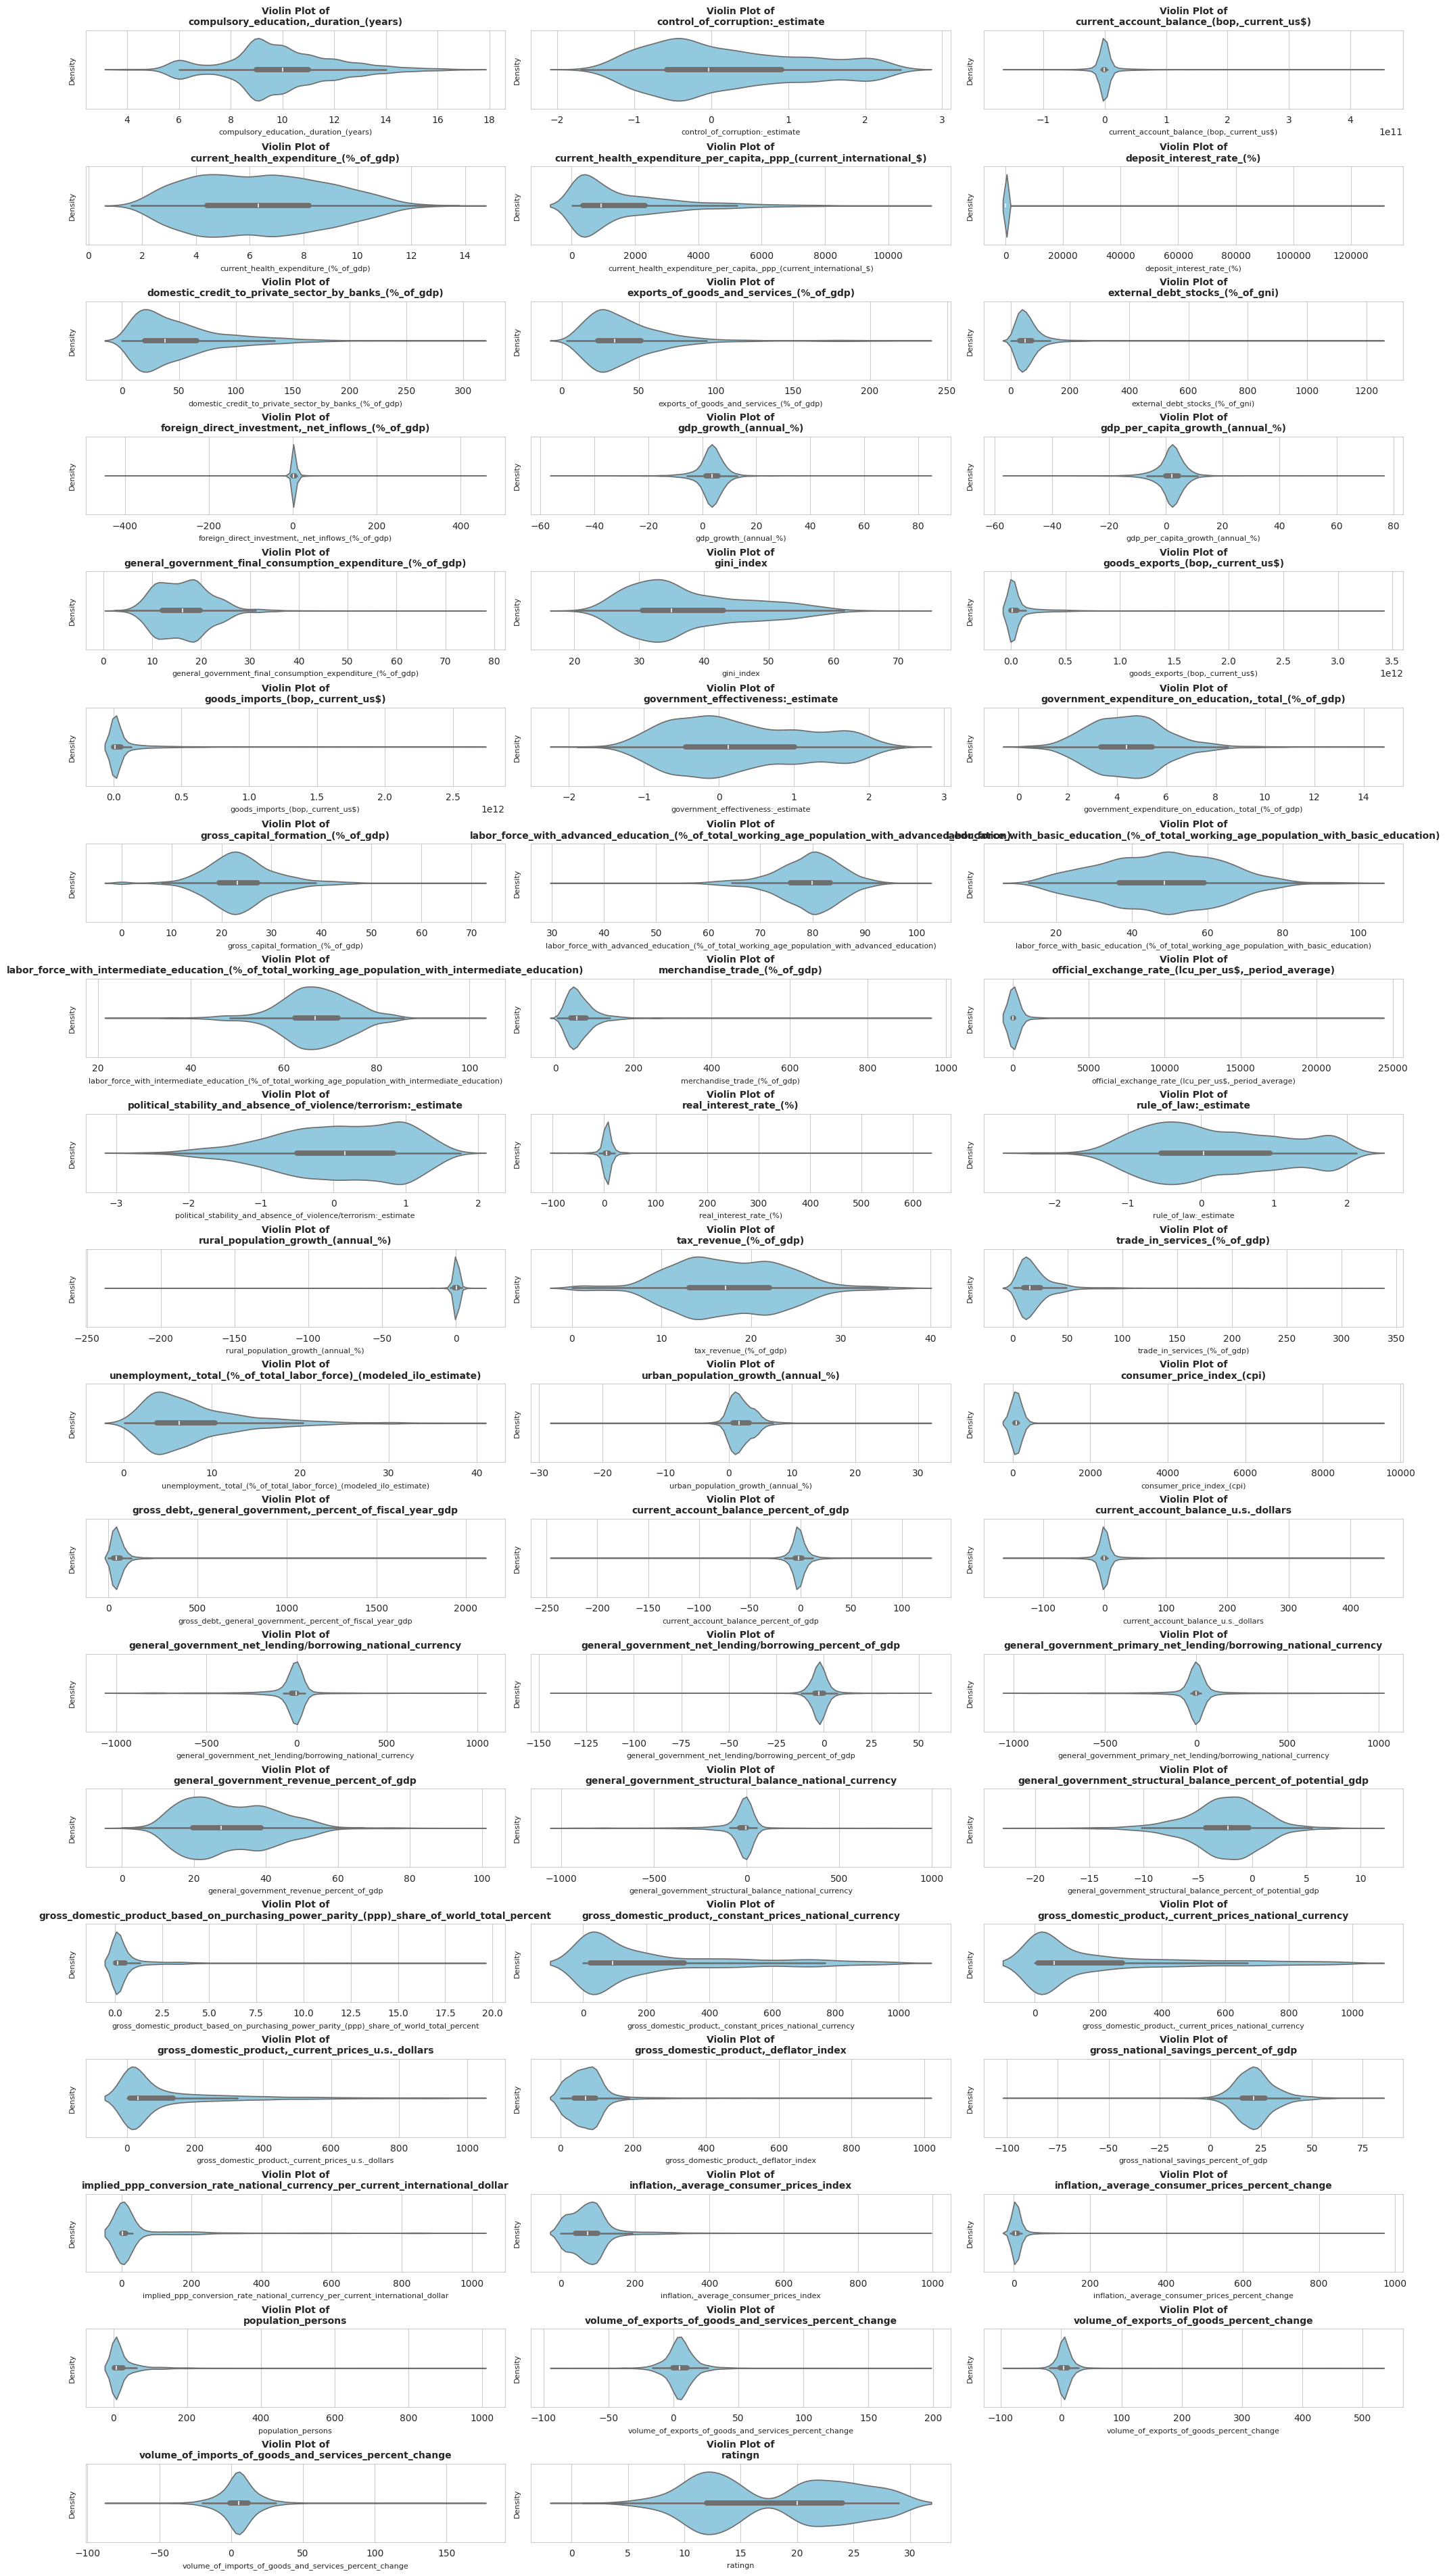

In [33]:
# Visualized the distributions of all numerical columns to check for outliers
# Select all numerical columns
numerical_columns = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Determine the number of subplots
num_cols = 3  # Number of columns for the grid
num_rows = (len(numerical_columns) + num_cols - 1) // num_cols

# Creating the figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 2 * num_rows), constrained_layout=True)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loopping through each numerical column to create a violin plot
for i, col in enumerate(numerical_columns):
    sns.violinplot(x=df_final[col], ax=axes[i], legend=False, color='skyblue')
    wrapped_title = f'Violin Plot of\n{col}'
    axes[i].set_title(wrapped_title, fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Density', fontsize=8)

# Hide any unused subplots
for i in range(len(numerical_columns), len(axes)):
    axes[i].axis('off')

# Save the plots to a file
plt.savefig("data/violin_plots.png")
plt.show();

##### Process outliers - No outliers identified - (might be revisited later only if required)

### 2.2 Imputation for missing data

#### 2.2.1 Inputation for missing country's ratings (Target columns)

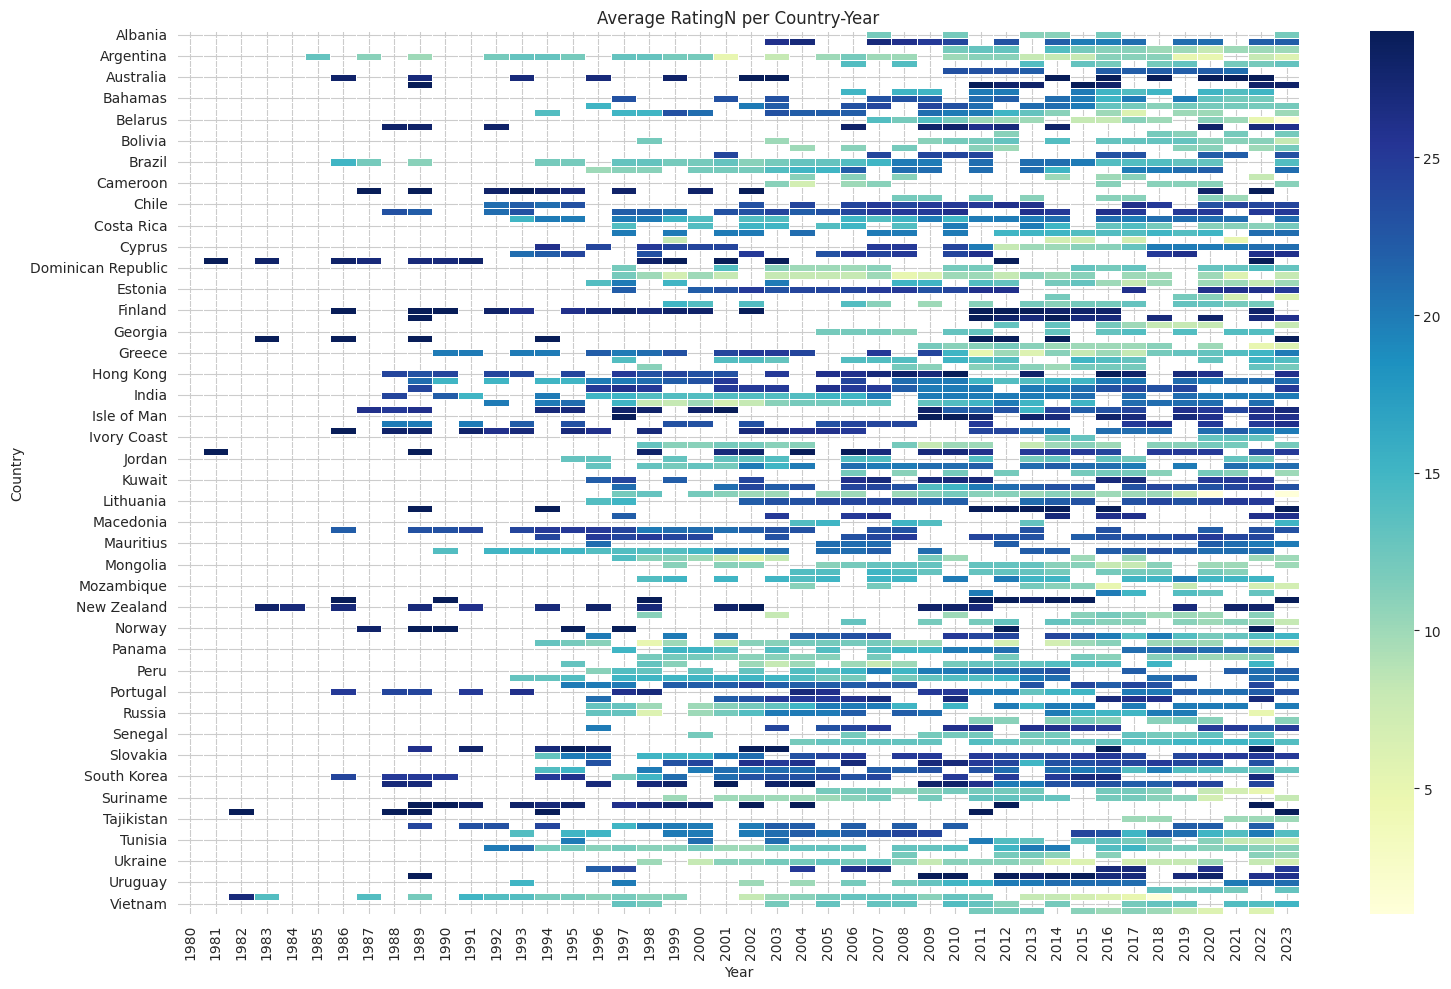

In [34]:
# Check distribution of rating by country and by year to assess the imputation technique for ratingn and outlookrank
# Compute the mean
dfx = df_final.groupby(['country', 'year'])['ratingn'].mean().unstack()
dfx = dfx.astype(float)

# Plot on heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(dfx, cmap='YlGnBu', annot=False, fmt='.1f', linewidths=0.5)
plt.title('Average RatingN per Country-Year')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [35]:
# Check distribution of rankingn across classes

print("="*50)
print('Distribution of rankingn labels across classes')
print("="*50)
print(df_final['ratingn'].value_counts())
print("="*50)

Distribution of rankingn labels across classes
ratingn
12    187
20    161
11    157
13    149
15    132
21    127
10    126
14    120
24    112
25    105
23    105
29     99
22     98
27     76
26     71
28     71
8      56
7      18
5      14
6      14
1       4
Name: count, dtype: Int64


In [36]:
# Check distriburion of outlook labels across classes

print("="*50)
print('Distribution of labels across classes')
print("="*50)
print(df_final['outlook'].value_counts())
print("="*50)


Distribution of labels across classes
outlook
Stable            1185
Negative           404
Positive           327
Negative Watch      46
Under Review         9
Positive Watch       8
Name: count, dtype: int64


In [37]:
# Combine classes by renaming "Watch" classes into their core class and "Under Review" replaced with majority class "Stable" 
df_final['outlook'] = df_final['outlook'].replace({
    'Negative Watch': 'Negative',
    'Positive Watch': 'Positive',
    'Under Review': 'Stable'
})

In [38]:
print("="*50)
print('Distribution of outlook labels across classes')
print("="*50)
print(df_final['outlook'].value_counts())
print("="*50)

Distribution of outlook labels across classes
outlook
Stable      1194
Negative     450
Positive     335
Name: count, dtype: int64


In [39]:
print("="*50)
print("NaN counts per column (after imputation):")
print(df_final[['ratingn','outlook']].isna().sum())
print("="*50)

NaN counts per column (after imputation):
ratingn    3498
outlook    3521
dtype: int64


In [40]:
# Imputation for ratingn should be in two stages: 
#1. Forward fill - fill in forward most of the missing values
#2. Backward fill - fill-in the missing values before the first available record

print("="*50)
print('Number of missing rating or outlook before imputation:')
print(df_final[['ratingn', 'outlook']].isna().sum());
print("="*50)
# Two-stage imputation by country
df_final[['ratingn', 'outlook']] = (
    df_final
    .sort_values(['country', 'year'])  # ensure chronological order
    .groupby('country')[['ratingn', 'outlook']]
    .transform(lambda x: x.ffill().bfill())
)

# Count remaining missing values
print("="*50)
print('Total number of countries without rating or outlook:')
print("="*50)
print(df_final[['ratingn', 'outlook']].isna().sum());
print("="*50)


Number of missing rating or outlook before imputation:
ratingn    3498
outlook    3521
dtype: int64
Total number of countries without rating or outlook:
ratingn    0
outlook    0
dtype: int64


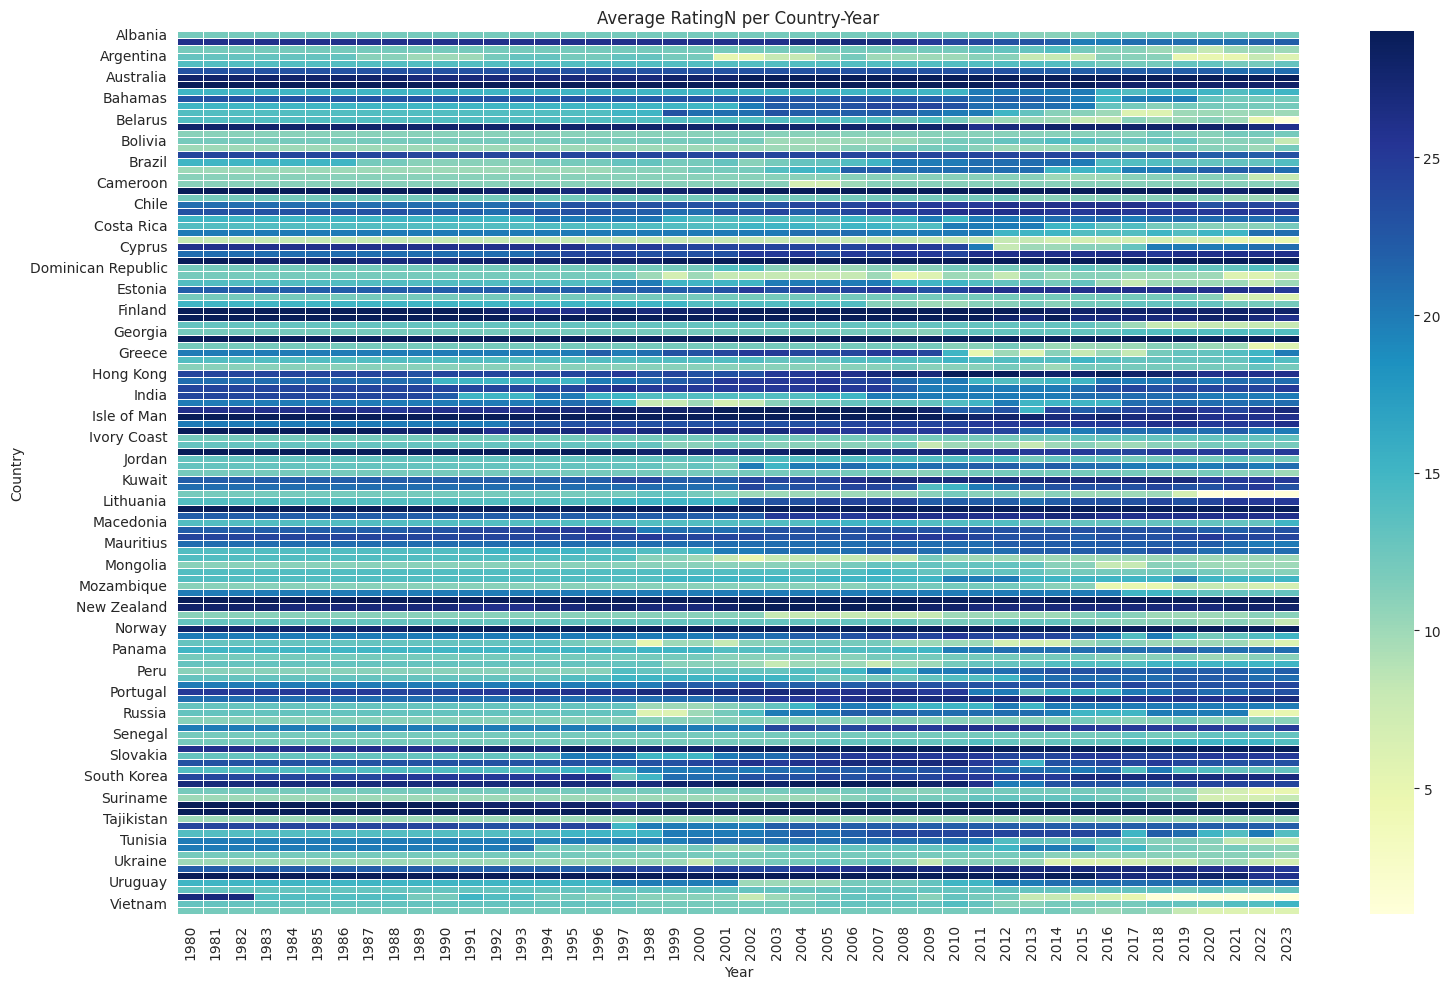

In [41]:
# Check distribution of rating by country and by year
# Compute the mean
#dfx = df_final.groupby(['country', 'year'])['ratingn'].mean().unstack()
dfx = df_final.pivot(index='country', columns='year', values='ratingn')
dfx = dfx.astype(float)

# Plot
plt.figure(figsize=(16, 10))
sns.heatmap(dfx, cmap='YlGnBu', annot=False, linewidths=0.5)
plt.title('Average RatingN per Country-Year')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [42]:
df_final.shape

(5500, 59)

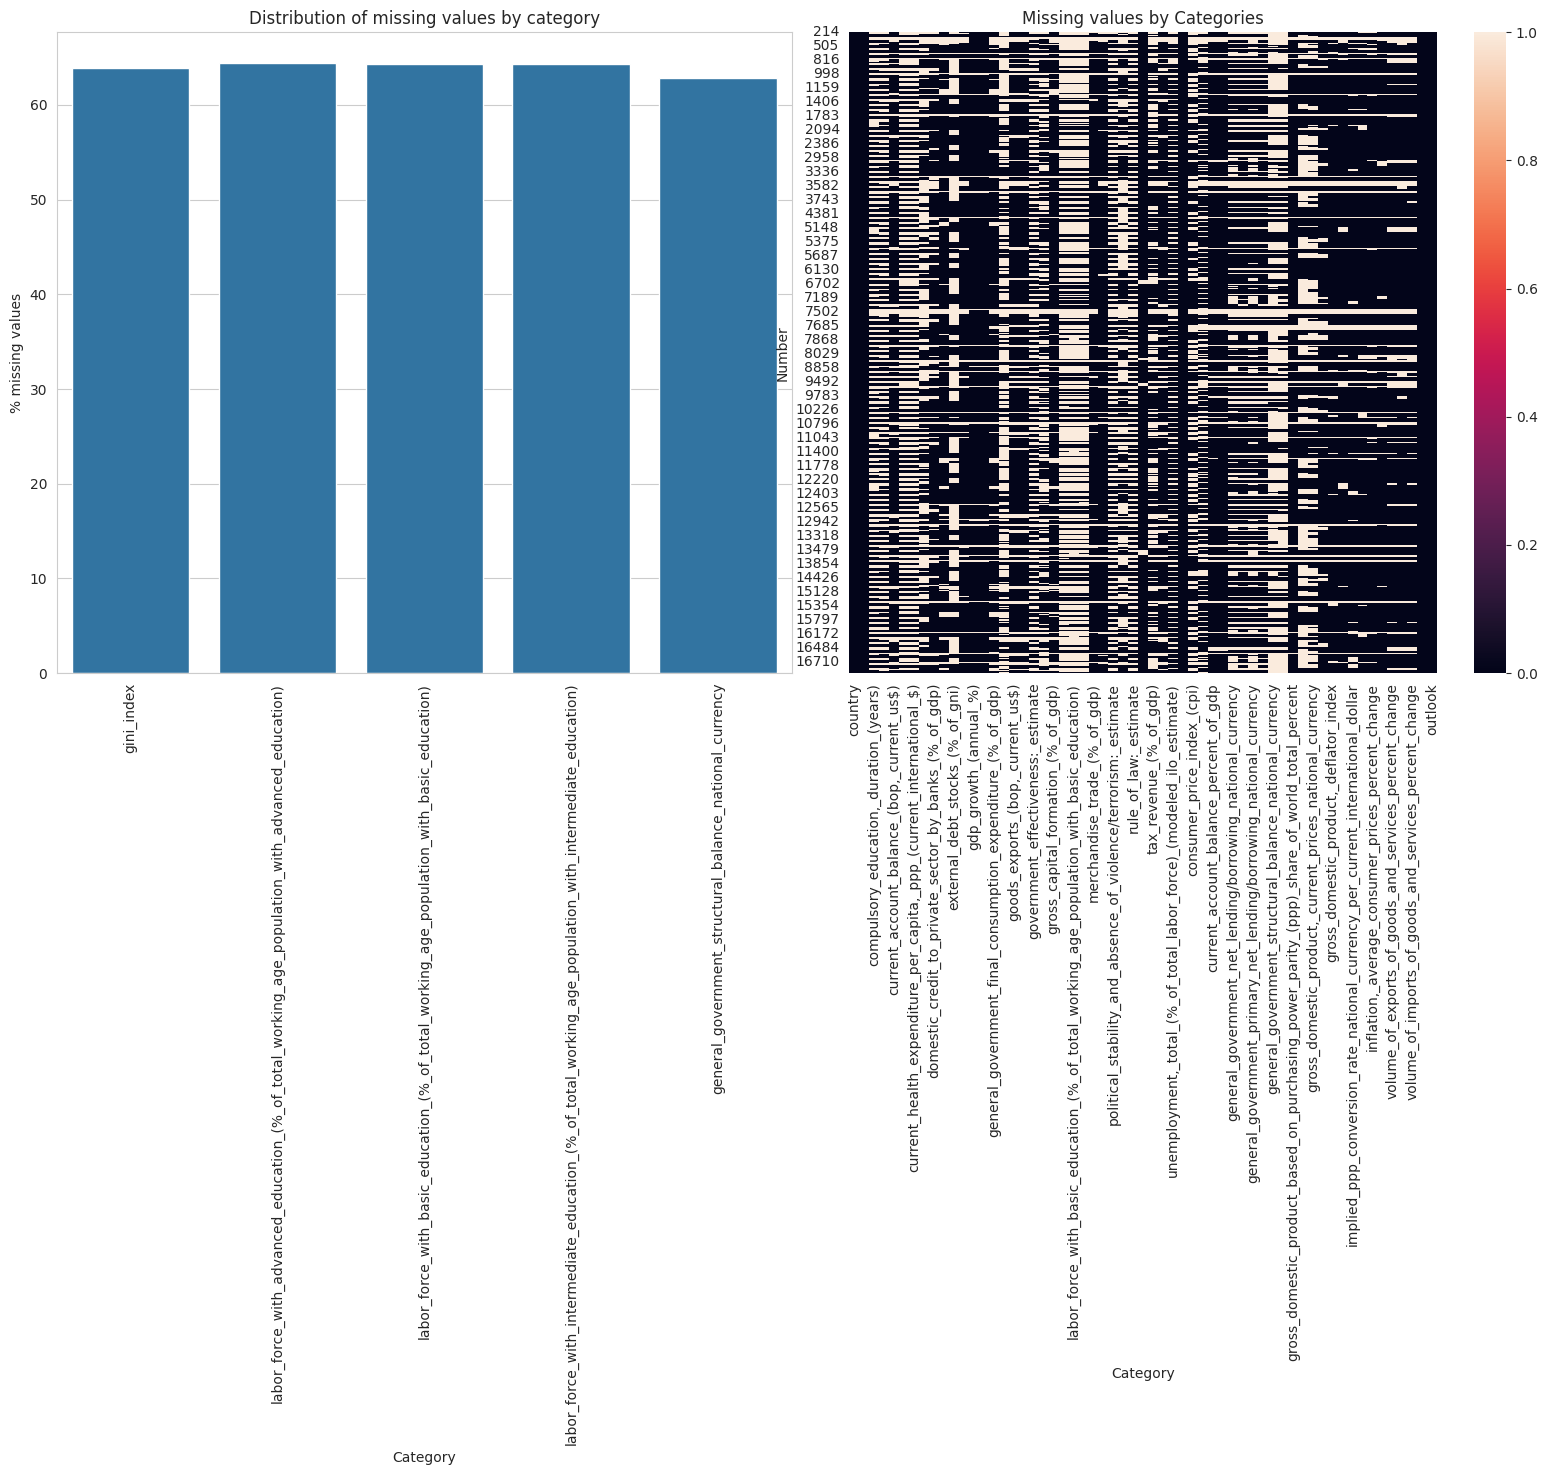

In [43]:
#Check missing values for each category and their distribution

missing_val = df_final.isna().mean().multiply(100).round(2)
missing_val_over60 = missing_val[missing_val >= 60]

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.tight_layout()

sns.barplot(data=missing_val_over60, ax=axes[0])
axes[0].set_title('Distribution of missing values by category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('% missing values')
axes[0].tick_params(axis='x', rotation=90)

sns.heatmap(data=df_final.isna(), ax=axes[1])
axes[1].set_title('Missing values by Categories')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number');

#### 2.2.3 Imputation for mising data in the rest of the columns (Features columns)

In [44]:
# Get the list of columns with NaNs for each country
all_nan_columns_by_country = (
    df_final
    .drop(columns=['country', 'year'])  # Exclude non-data columns
    .groupby(df_final['country'])
    .apply(lambda x: x.columns[x.isna().all()].tolist())
)

# Filter for countries that have at least one column with all NaNs
countries_with_all_nan_cols = all_nan_columns_by_country[all_nan_columns_by_country.apply(len) > 0]

# Flatten the lists of columns and get unique values
all_unique_empty_columns = set(
    [col for sublist in countries_with_all_nan_cols for col in sublist]
)

print("Unique columns with all NaNs across any country:")
print("="*110)
print(list(all_unique_empty_columns))
print("="*110)

Unique columns with all NaNs across any country:
['labor_force_with_advanced_education_(%_of_total_working_age_population_with_advanced_education)', 'general_government_revenue_percent_of_gdp', 'domestic_credit_to_private_sector_by_banks_(%_of_gdp)', 'external_debt_stocks_(%_of_gni)', 'general_government_net_lending/borrowing_national_currency', 'real_interest_rate_(%)', 'control_of_corruption:_estimate', 'general_government_final_consumption_expenditure_(%_of_gdp)', 'gross_debt,_general_government,_percent_of_fiscal_year_gdp', 'volume_of_imports_of_goods_and_services_percent_change', 'general_government_structural_balance_percent_of_potential_gdp', 'gross_national_savings_percent_of_gdp', 'general_government_primary_net_lending/borrowing_national_currency', 'gross_domestic_product,_constant_prices_national_currency', 'gini_index', 'political_stability_and_absence_of_violence/terrorism:_estimate', 'goods_exports_(bop,_current_us$)', 'implied_ppp_conversion_rate_national_currency_per_cu

In [45]:
# Checking for columns that have only NaNs to the entire serie
print("Distribution of NaNs across different features:")
print("="*112)
print(df_final.isna().mean().multiply(100).sort_values(ascending=False).round(2).head(10))
print("="*112)

Distribution of NaNs across different features:
labor_force_with_advanced_education_(%_of_total_working_age_population_with_advanced_education)            64.45
labor_force_with_intermediate_education_(%_of_total_working_age_population_with_intermediate_education)    64.36
labor_force_with_basic_education_(%_of_total_working_age_population_with_basic_education)                  64.35
gini_index                                                                                                 63.95
general_government_structural_balance_national_currency                                                    62.89
general_government_structural_balance_percent_of_potential_gdp                                             59.82
external_debt_stocks_(%_of_gni)                                                                            53.96
gross_domestic_product,_constant_prices_national_currency                                                  50.09
current_health_expenditure_per_capita,_ppp_(curr

In [46]:
# ================================================
# Define Imputation Strategy for each column
# ================================================

poly_interpolate_cols = []

ffill_bfill_cols = ['compulsory_education,_duration_(years)']

mean_fill_cols = []

rolling_avg_cols = []

arima_cols = [
        'control_of_corruption:_estimate',
       'current_account_balance_(bop,_current_us$)',
       'current_health_expenditure_(%_of_gdp)',
       'current_health_expenditure_per_capita,_ppp_(current_international_$)',
       'deposit_interest_rate_(%)',
       'domestic_credit_to_private_sector_by_banks_(%_of_gdp)',
       'exports_of_goods_and_services_(%_of_gdp)',
       'external_debt_stocks_(%_of_gni)',
       'foreign_direct_investment,_net_inflows_(%_of_gdp)',
       'gdp_growth_(annual_%)', 'gdp_per_capita_growth_(annual_%)',
       'general_government_final_consumption_expenditure_(%_of_gdp)',
       'gini_index', 'goods_exports_(bop,_current_us$)',
       'goods_imports_(bop,_current_us$)',
       'government_effectiveness:_estimate',
       'government_expenditure_on_education,_total_(%_of_gdp)',
       'gross_capital_formation_(%_of_gdp)',
       'labor_force_with_advanced_education_(%_of_total_working_age_population_with_advanced_education)',
       'labor_force_with_basic_education_(%_of_total_working_age_population_with_basic_education)',
       'labor_force_with_intermediate_education_(%_of_total_working_age_population_with_intermediate_education)',
       'merchandise_trade_(%_of_gdp)',
       'official_exchange_rate_(lcu_per_us$,_period_average)',
       'political_stability_and_absence_of_violence/terrorism:_estimate',
       'real_interest_rate_(%)', 'rule_of_law:_estimate',
       'rural_population_growth_(annual_%)', 'tax_revenue_(%_of_gdp)',
       'trade_in_services_(%_of_gdp)',
       'unemployment,_total_(%_of_total_labor_force)_(modeled_ilo_estimate)',
       'urban_population_growth_(annual_%)', 'consumer_price_index_(cpi)',
       'gross_debt,_general_government,_percent_of_fiscal_year_gdp',
       'current_account_balance_percent_of_gdp',
       'current_account_balance_u.s._dollars',
       'general_government_net_lending/borrowing_national_currency',
       'general_government_net_lending/borrowing_percent_of_gdp',
       'general_government_primary_net_lending/borrowing_national_currency',
       'general_government_revenue_percent_of_gdp',
       'general_government_structural_balance_national_currency',
       'general_government_structural_balance_percent_of_potential_gdp',
       'gross_domestic_product_based_on_purchasing_power_parity_(ppp)_share_of_world_total_percent',
       'gross_domestic_product,_constant_prices_national_currency',
       'gross_domestic_product,_current_prices_national_currency',
       'gross_domestic_product,_current_prices_u.s._dollars',
       'gross_domestic_product,_deflator_index',
       'gross_national_savings_percent_of_gdp',
       'implied_ppp_conversion_rate_national_currency_per_current_international_dollar',
       'inflation,_average_consumer_prices_index',
       'inflation,_average_consumer_prices_percent_change',
       'population_persons',
       'volume_of_exports_of_goods_and_services_percent_change',
       'volume_of_exports_of_goods_percent_change',
       'volume_of_imports_of_goods_and_services_percent_change'
        ]

# ================================================
# Imputation Helper Functions
# ================================================

def smart_interpolate(series, method='polynomial', order=2):
    min_points = order + 1 if method == 'polynomial' else 2
    if series.notna().sum() >= min_points:
        return series.interpolate(method=method, order=order)
    else:
        return series.interpolate(method='linear', limit_direction='both')

def impute_with_arima(series):
    s = series.copy()
    if s.isnull().all() or s.notna().sum() < 3:
        return s.interpolate(method='linear', limit_direction='both')
    try:
        model = ARIMA(s.dropna(), order=(3, 2, 0))
        model_fit = model.fit()
        forecast = model_fit.predict(start=s.index[0], end=s.index[-1])
        s[s.isna()] = forecast[s.isna()]
        # Fallback if still NaNs remain
        if s.isna().any():
            s = s.interpolate(method='linear', limit_direction='both')
        return s
    except Exception:
        return s.interpolate(method='linear', limit_direction='both')



# ================================================
# Main Imputation Pipeline
# ================================================

def run_staged_imputation(df, poly_cols, ffill_cols, mean_cols, arima_cols):
    df_imputed = df.copy().sort_values(['country', 'year'])
    imputation_log = {
        'sparse_imputation': 0,
        'poly_or_linear': 0,
        'ffill_bfill': 0,
        'mean': 0,
        'arima': 0,
        'global_fallback': 0
    }

    all_imputation_cols = list(set(poly_cols + ffill_cols + arima_cols + mean_cols))
    for col in all_imputation_cols:
        if col in df_imputed.columns and pd.api.types.is_numeric_dtype(df_imputed[col]):
            df_imputed[col] = df_imputed[col].astype('float64')

    initial_total_missing = df_imputed.isnull().sum().sum()

    # Stage 1: Impute series with only NaNs with global median
    all_nan_columns_by_country = df_imputed.groupby('country').apply(
        lambda x: x.columns[x.isna().all()].tolist()
    )
    for country, empty_cols in all_nan_columns_by_country.items():
        if empty_cols:
            for col in empty_cols:
                if col in all_imputation_cols:
                    median_val = df_imputed[col].median()
                    df_imputed.loc[df_imputed['country'] == country, col] = df_imputed.loc[df_imputed['country'] == country, col].fillna(median_val)
    imputation_log['sparse_imputation'] = initial_total_missing - df_imputed.isnull().sum().sum()

    # Stage 2: Impute with Polynomial/Linear Interpolation
    missing_before = df_imputed.isnull().sum().sum()
    if poly_cols:
        df_imputed = df_imputed.sort_values(by=['country', 'year'])
        df_imputed[poly_cols] = df_imputed.groupby('country')[poly_cols].transform(smart_interpolate)
    imputation_log['poly_or_linear'] = missing_before - df_imputed.isnull().sum().sum()

    # Stage 3: Impute with Forward/Backward Fill
    missing_before = df_imputed.isnull().sum().sum()
    if ffill_cols:
        df_imputed = df_imputed.sort_values(by=['country', 'year'])
        df_imputed[ffill_cols] = df_imputed.groupby('country')[ffill_cols].transform(lambda x: x.ffill().bfill())
    imputation_log['ffill_bfill'] = missing_before - df_imputed.isnull().sum().sum()

    # Stage 4: Impute with Mean
    missing_before = df_imputed.isnull().sum().sum()
    if mean_cols:
        for col in mean_cols:
            df_imputed[col] = df_imputed.groupby(['country', 'year'])[col].transform(lambda x: x.fillna(x.mean()))
    imputation_log['mean'] = missing_before - df_imputed.isnull().sum().sum()

    # Stage 5: Impute with ARIMA
    missing_before = df_imputed.isnull().sum().sum()
    if arima_cols:
        for col in arima_cols:
            df_imputed = df_imputed.sort_values(by=['country', 'year'])
            df_imputed[col] = df_imputed.groupby('country')[col].transform(impute_with_arima)
    imputation_log['arima'] = missing_before - df_imputed.isnull().sum().sum()


    # Stage 6: Global Fallback for any remaining NaNs
    missing_before = df_imputed.isnull().sum().sum()  
    for col in df_imputed.columns:
        if df_imputed[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_imputed[col]):
                mean_val = df_imputed[col].mean()
                # Fallback if mean is NaN (e.g., all values are missing)
                if pd.isna(mean_val):
                    df_imputed[col] = df_imputed[col].fillna(0)
                else:
                    df_imputed[col] = df_imputed[col].fillna(mean_val)
            else:
                mode_series = df_imputed[col].mode()
                if not mode_series.empty:
                    df_imputed[col] = df_imputed[col].fillna(mode_series[0])
                else:
                    df_imputed[col] = df_imputed[col].fillna("missing")            
    imputation_log['global_fallback'] = missing_before - df_imputed.isnull().sum().sum()

    return df_imputed, imputation_log

df_final_imputed, imputation_log_results = run_staged_imputation(
    df_final,
    poly_interpolate_cols,
    ffill_bfill_cols,
    mean_fill_cols,
    arima_cols
)

print("="*112)
print(imputation_log_results)
print("="*112)

missing_summary = df_final_imputed.isnull().sum()
print("Columns still with missing values:")
print(missing_summary[missing_summary > 0])

{'sparse_imputation': np.int64(20768), 'poly_or_linear': np.int64(0), 'ffill_bfill': np.int64(2267), 'mean': np.int64(0), 'arima': np.int64(63906), 'global_fallback': np.int64(0)}
Columns still with missing values:
Series([], dtype: int64)


In [47]:
# Copy the dataframe into the working DataFrame
dfc = df_final_imputed.copy()

## 3. Modeling

### 3.1 Features Engineering

#### 3.1.1 PCA Analysis

In [48]:
# Separate imputs from targets
X_features = dfc.drop(columns=['ratingn', 'outlook', 'country']).copy()
y_targets = dfc[['ratingn', 'outlook', 'country']].copy()

# Select columns by type from the features DataFrame
numerical_columns = X_features.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = X_features.select_dtypes(include=['object', 'int32']).columns.tolist()

# Split before preprocessing to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_targets, test_size=0.2, random_state=42
)

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_columns)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert X_train_processed to dense array
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

# Get the feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame and clean column names
df_preprocessed = pd.DataFrame(X_train_processed, columns=feature_names)
df_preprocessed.columns = df_preprocessed.columns.str.replace('num__', '', regex=False)
df_preprocessed.columns = df_preprocessed.columns.str.replace('cat__', '', regex=False)
df_preprocessed.columns = df_preprocessed.columns.str.replace('remainder__', '', regex=False)

# Run PCA on training data only
pca = PCA(n_components=0.9)
X_train_pca = pca.fit_transform(df_preprocessed)

# Get the first principal component's feature contributions
top_features = pd.Series(pca.components_[0], index=df_preprocessed.columns).sort_values(ascending=False)

# Filter the column of interest
filtered_features = top_features[(top_features.abs() >= 0.01) & (top_features.abs() < 0.99)]
filtered_features = filtered_features.reindex(filtered_features.abs().sort_values(ascending=False).index)

# Display the top features for the first principal component
print("="*120)
print("Top features for the first principal component:")
print("="*112)
print(filtered_features)
print("="*112)

# Get the list of PCA-filtered feature names
pca_features_list = filtered_features.index.to_list()

Top features for the first principal component:
gross_domestic_product_based_on_purchasing_power_parity_(ppp)_share_of_world_total_percent    0.332766
general_government_final_consumption_expenditure_(%_of_gdp)                                  -0.327881
inflation,_average_consumer_prices_percent_change                                             0.302983
general_government_revenue_percent_of_gdp                                                    -0.285490
volume_of_exports_of_goods_percent_change                                                     0.284780
general_government_structural_balance_national_currency                                       0.279898
general_government_net_lending/borrowing_national_currency                                    0.275721
general_government_net_lending/borrowing_percent_of_gdp                                       0.267285
volume_of_exports_of_goods_and_services_percent_change                                        0.243329
general_government_struct

In [49]:
# Extract base (original) column names
base_feature_names = [col.split('_')[0] for col in pca_features_list]

# Match numerical columns
final_raw_features = list(set(pca_features_list) & set(numerical_columns))

columns_to_keep = ['country', 'ratingn', 'outlook'] + final_raw_features
dfc_selected = dfc[columns_to_keep].copy()
dfc_selected.sample(3)

,country,ratingn,outlook,general_government_revenue_percent_of_gdp,domestic_credit_to_private_sector_by_banks_(%_of_gdp),external_debt_stocks_(%_of_gni),general_government_net_lending/borrowing_national_currency,real_interest_rate_(%),control_of_corruption:_estimate,general_government_final_consumption_expenditure_(%_of_gdp),...,consumer_price_index_(cpi),"gross_domestic_product,_current_prices_u.s._dollars",merchandise_trade_(%_of_gdp),gdp_growth_(annual_%),"compulsory_education,_duration_(years)","inflation,_average_consumer_prices_index","goods_imports_(bop,_current_us$)","current_health_expenditure_per_capita,_ppp_(current_international_$)","official_exchange_rate_(lcu_per_us$,_period_average)",urban_population_growth_(annual_%)
8874,Lebanon,10,Stable,19.39900,99.789882,138.108135,-930.399000,7.414932,-0.990380,12.984149,...,96.274325,51.150,45.550784,1.554549,10.0,96.242,1.770921e+10,1301.000000,1507.5000,-2.154013
14486,Sri Lanka,12,Stable,18.44900,8.798534,73.726845,-36.320000,11855.450199,-241.750515,9.838456,...,697683.945265,10.716,56.008855,4.599987,9.0,10.306,2.808021e+09,382155.955596,41.3715,0.667791
1061,Bahamas,23,Stable,592.08557,27.385238,48.798770,-62.951459,4.385244,46.779322,12.137513,...,3831.703732,4.241,242.305359,1.797000,12.0,48.291,9.409000e+08,368231.521819,1.0000,2.590032


In [50]:
# Update the working df
dfc = dfc_selected.copy()

#### 3.2.1 Correlations and multi-colinearity per target - Stage II (post-imputation)

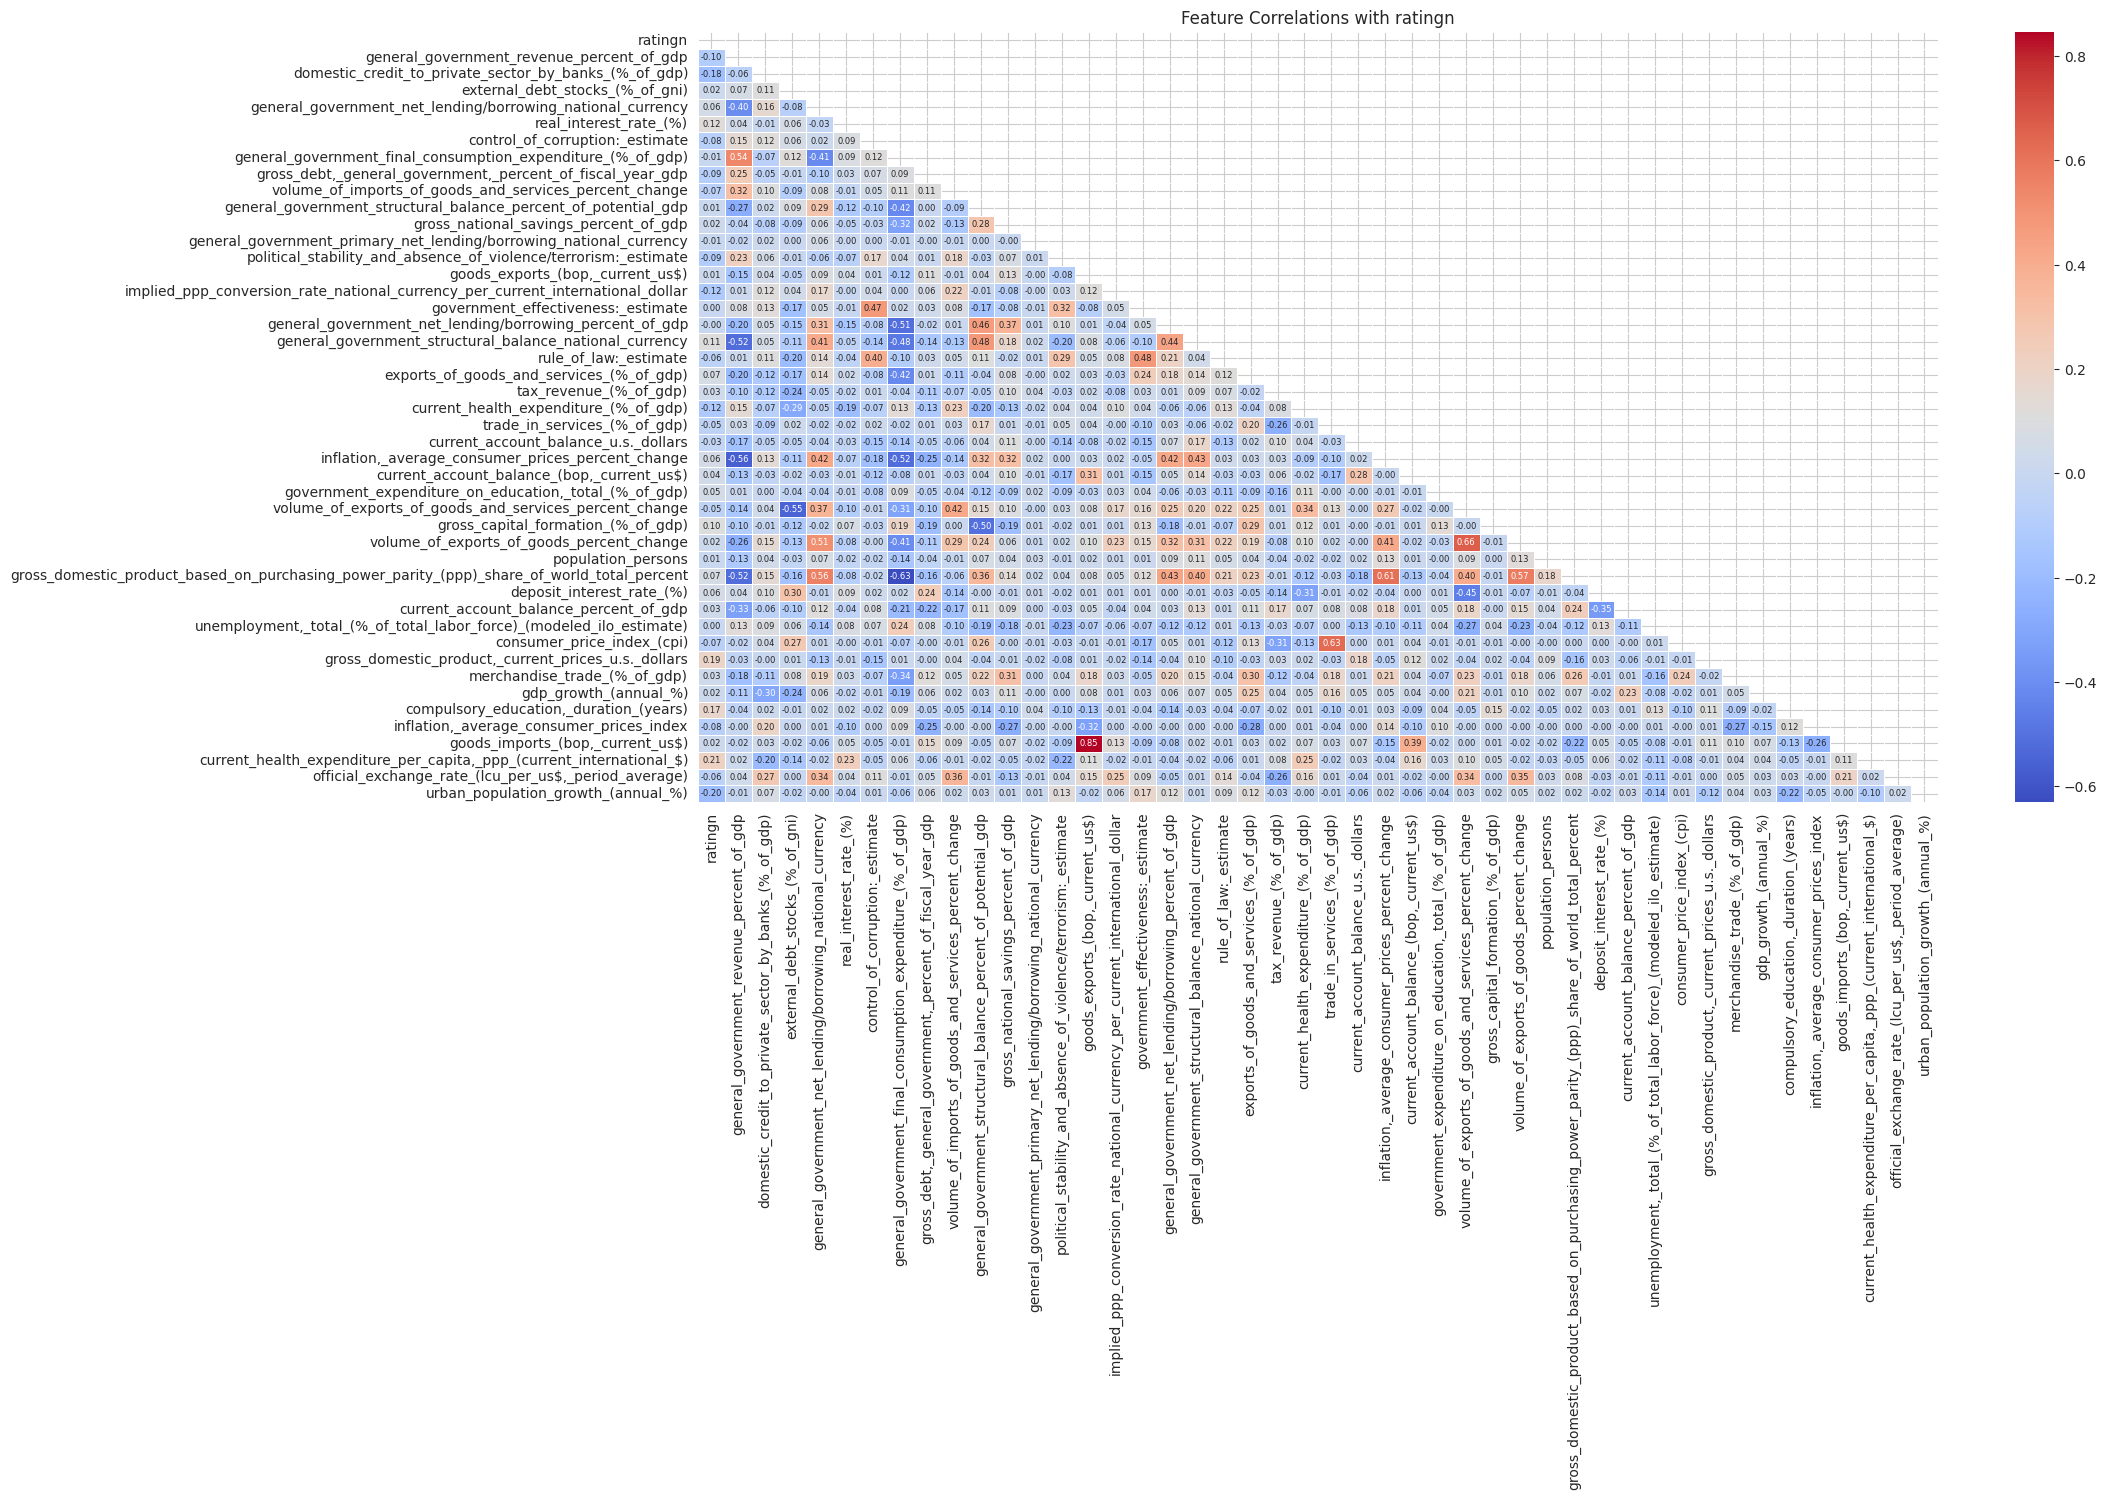

In [51]:
# Plot the heatmap for correlation
plt.figure(figsize=(20, 10))
mask = np.triu(np.ones_like(dfc.corr(numeric_only=True))).astype(bool)
sns.heatmap(dfc.corr(numeric_only=True), mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 6})
plt.title('Feature Correlations with ratingn')
plt.show()

### 3.2 Classification Models

#### 3.2.1 Build the model dataframe

In [52]:
# Creating Classification dataframe
dfcl = dfc.copy()

# Creating train and target dataframes.
Xr = dfcl.drop(['ratingn', 'outlook', 'country'], axis=1) # Remove Country column because I need a general model rather than country based.
Xo = dfcl.drop(['outlook', 'ratingn', 'country'], axis=1) # Remove Country column because I need a general model rather than country based.
yr = dfcl['ratingn']   # Prediction for the country rating
yo = dfcl['outlook'] # Prediction for country outlook

In [53]:
# Instantiate the label encoder
le_yr = LabelEncoder()
le_yo = LabelEncoder()

# Fit and transform the targets
# At the end I will have to decode by using le_yr.inverse_transform() and le_yo.inverse_transform()
yr_encoded = le_yr.fit_transform(yr)
yo_encoded = le_yo.fit_transform(yo)

# Splitting data into training and testing sets. I have two targets country rating (yr) and country outlook (yo) 
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr_encoded, test_size=0.2, random_state=42)
Xo_train, Xo_test, yo_train, yo_test = train_test_split(Xo, yo_encoded, test_size=0.2, random_state=42)

#### 3.2.2 Split dataset in Train and test datasets

#### 3.2.3 Define data Pre-Processor

In [54]:
# Treat year as categorical column although contains numerical values (int32). This is key!!!
# Defining the preprocessor
categorical_columns_Xr = Xr_train.select_dtypes(include=['object', 'int32']).columns.tolist() 
numerical_columns_Xr = Xr_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

categorical_columns_Xo = Xo_train.select_dtypes(include=['object', 'int32']).columns.tolist() 
numerical_columns_Xo = Xo_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

preprocessor_Xr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns_Xr),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_columns_Xr)
    ],
    remainder='passthrough'
)

preprocessor_Xo = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns_Xo),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_columns_Xo)
    ],
    remainder='passthrough'
)

#### 3.2.4 Define the Baseline Model accuracy for Classification Model

In [55]:
# Defining the baseline model score. Create a shallow Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=40, random_state=42)

# Create a pipeline that first preprocesses the data and then runs the model
dt_pipeline_ratingn = Pipeline(steps=[
    ('preprocessor', preprocessor_Xr),
    ('smote', BorderlineSMOTE(kind='borderline-1', random_state=42, k_neighbors=3, m_neighbors=5)),
    ('classifier', dt_model)
])

# Create a pipeline that first preprocesses the data and then runs the model
dt_pipeline_outlook = Pipeline(steps=[
    ('preprocessor', preprocessor_Xo),
    ('smote', ADASYN(random_state=42, n_neighbors=3)),
    ('classifier', dt_model)
])

# Use the pipeline with cross-validation for the 'ratingn' target
baseline_score_yr = cross_val_score(dt_pipeline_ratingn, Xr_train, yr_train, cv=5, scoring='f1_macro')

# Use the pipeline with cross-validation for the 'outlookrank' target
baseline_score_yo = cross_val_score(dt_pipeline_outlook, Xo_train, yo_train, cv=5, scoring='f1_macro')

print("="*65)
print(f"Baseline F1-Score using a Decision Tree for yr: {baseline_score_yr.mean():.4f}")
print(f"Baseline F1-Score using a Decision Tree for yo: {baseline_score_yo.mean():.4f}")
print("="*65)

Baseline F1-Score using a Decision Tree for yr: 0.5261
Baseline F1-Score using a Decision Tree for yo: 0.5271


## 4. Experimentation

### 4.1 Models set-up and experimentation for Country Ratings

Training Models:   0%|                                    | 0/5 [00:00<?, ?it/s]

Training RANDOMFOREST on the full data.


Training Models:  20%|█████▍                     | 1/5 [02:06<08:27, 127.00s/it]

Training XGBOOST on the full data.


Training Models:  40%|██████████▊                | 2/5 [05:54<09:18, 186.00s/it]

...

Training EXTRATREES on the full data.


Training Models:  80%|█████████████████████▌     | 4/5 [14:39<03:31, 211.13s/it]

Training LIGHTGBM on the full data.


Training Models: 100%|███████████████████████████| 5/5 [55:11<00:00, 662.27s/it]


Feature Importances of the Best Model
num__gross_debt,_general_government,_percent_of_fiscal_year_gdp                                    0.036489
num__domestic_credit_to_private_sector_by_banks_(%_of_gdp)                                         0.035105
num__government_effectiveness:_estimate                                                            0.034193
num__rule_of_law:_estimate                                                                         0.031390
num__control_of_corruption:_estimate                                                               0.030400
num__merchandise_trade_(%_of_gdp)                                                                  0.029279
num__goods_exports_(bop,_current_us$)                                                              0.029060
num__implied_ppp_conversion_rate_national_currency_per_current_international_dollar                0.028147
num__urban_population_growth_(annual_%)                                                           

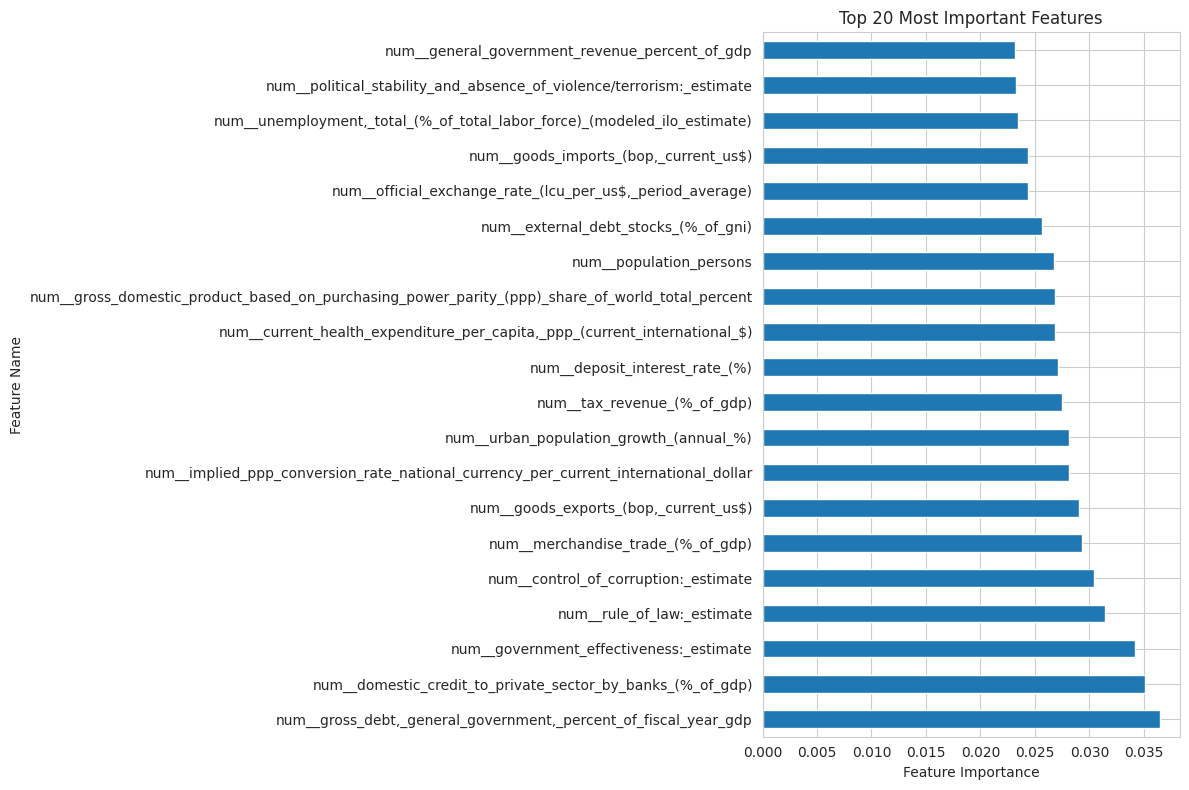

Multiclass Model Results


,train score,test score,accuracy,recall,precision,f1_score,average fit time
model,,,,,,,
randomforest,100.00%,77.91%,77.91%,72.37%,73.25%,71.10%,6.34s
xgboost,99.98%,77.18%,77.18%,70.65%,70.20%,69.57%,11.36s
histgradientboosting,98.59%,75.91%,75.91%,68.98%,69.03%,68.25%,24.22s
extratrees,99.39%,77.18%,77.18%,70.46%,67.65%,68.66%,1.94s
lightgbm,99.68%,76.00%,76.00%,69.80%,69.96%,69.09%,121.56s


Overall Best Model and Parameters
Best Model: randomforest
Best Test Score: 77.91%
Best Parameters: {'randomforest__n_estimators': 100, 'randomforest__min_samples_split': 2, 'randomforest__min_samples_leaf': 1, 'randomforest__max_depth': 25}


In [56]:
def get_processed_feature_names(preprocessor):
    """
    This function gets the feature names after preprocessing.
    """
    return preprocessor.get_feature_names_out()


# Defining the models and hyperparameters
best_overall_model_yr = None
best_overall_score_yr = 0.0
best_overall_params_yr = {}
best_model_for_final_eval_yr = None

models = {
    'randomforest': (RandomForestClassifier(class_weight='balanced', random_state=42),
                     {'randomforest__n_estimators': [100, 200, 300],
                      'randomforest__max_depth': [25, 50],
                      'randomforest__min_samples_leaf': [1, 5, 10, 15],
                      'randomforest__min_samples_split': [2, 5, 10, 15]
                     }),
    
    'xgboost': (XGBClassifier(objective="multi:softprob", random_state=42, num_class=21),
               {'xgboost__n_estimators': [100, 200, 300],
                'xgboost__learning_rate': [0.01, 0.05, 0.1],
                'xgboost__max_depth': [25, 50],
                'xgboost__min_child_weight':[2, 4, 6],
                'xgboost__subsample': [0.6, 0.4],
                'xgboost__colsample_bytree': [0.8, 1]
               }),
    
    'histgradientboosting': (HistGradientBoostingClassifier(random_state=42),
                             {'histgradientboosting__max_iter': [200, 300, 400],
                              'histgradientboosting__learning_rate': [0.01, 0.1, 0.3],
                              'histgradientboosting__max_leaf_nodes': [15, 31, 50]
                             }),

    'extratrees': (ExtraTreesClassifier(class_weight='balanced', random_state=42),
                   {'extratrees__n_estimators': [100, 200, 300],
                    'extratrees__max_depth': [10, 40],
                    'extratrees__min_samples_leaf': [1, 5, 10],
                    'extratrees__min_samples_split': [2, 5, 10]
                   }),
    
    'lightgbm': (LGBMClassifier(random_state=42, verbose=-1),
                {'lightgbm__n_estimators': [100, 200],
                 'lightgbm__num_leaves': [ 5, 10],
                 'lightgbm__learning_rate': [0.01, 0.1],
                 'lightgbm__max_depth': [8, 30],
                 'lightgbm__min_child_samples': [10, 15]
                }),
}

results = []
yr_pred_probas = {}

# Wrap the loop iterable with tqdm()
for name, (model, params) in tqdm(models.items(), desc="Training Models"):
    # --- Creating the pipeline ---
    pipeline = Pipeline([
        ('preprocessor', preprocessor_Xr),
        ('smote', BorderlineSMOTE(kind='borderline-1', random_state=42, k_neighbors=3, m_neighbors=5)),
        (name, model)
    ])

    # I will select the best model based on F1-score
    f1_scorer = make_scorer(f1_score, average='macro')
    #grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring=f1_scorer)
    
    grid_search = RandomizedSearchCV(
        pipeline,
        param_distributions=params,
        n_iter=20, 
        cv=5,
        n_jobs=-1,
        scoring=f1_scorer,
        random_state=42
    )
    
    print(f"Training {name.upper()} on the full data.")
    start_time = time.time()
    
    grid_search.fit(Xr_train, yr_train)

    # Calculate the total duration for the entire grid search
    total_duration = time.time() - start_time
    fit_time = total_duration / len(grid_search.cv_results_['mean_fit_time'])
    
    best_model = grid_search.best_estimator_
    
    # --- Evaluate on preprocessed data ---
    train_score_yr = best_model.score(Xr_train, yr_train)
    test_score_yr = best_model.score(Xr_test, yr_test)
    
    if test_score_yr > best_overall_score_yr:
        best_overall_score_yr = test_score_yr
        best_overall_model_yr = name
        best_overall_params_yr = grid_search.best_params_
        best_model_for_final_eval_yr = best_model

    yr_pred = best_model.predict(Xr_test)
    
    # Calculate probabilities
    yr_pred_proba = best_model.predict_proba(Xr_test)
    
    # Store probabilities
    # For multiclass, ROC curve plotting needs to be handled differently (one-vs-rest)
    yr_pred_probas[name] = yr_pred_proba

    # Calculating metrics using the current predictions
    accuracy = accuracy_score(yr_test, yr_pred)
    recall = recall_score(yr_test, yr_pred, average='macro', zero_division=0)
    precision = precision_score(yr_test, yr_pred, average='macro', zero_division=0)
    f1 = f1_score(yr_test, yr_pred, average='macro', zero_division=0)

    # --- Metrics for the results DataFrame ---
    results.append([name, train_score_yr, test_score_yr, accuracy, recall, precision, f1, fit_time])

preprocessor_fitted_Xr = best_model_for_final_eval_yr.named_steps['preprocessor']
processed_feature_names_ratingn = get_processed_feature_names(preprocessor_fitted_Xr)

# Access the best model from the fitted pipeline
best_classifier_ratingn = best_model_for_final_eval_yr.named_steps[best_overall_model_yr]

# Check if the best classifier has the `feature_importances_` attribute
if hasattr(best_classifier_ratingn, 'feature_importances_'):
    importances_ratingn = best_classifier_ratingn.feature_importances_

    # Create a pandas Series to easily view the importances with their corresponding names
    feature_importances_ratingn_df = pd.Series(importances_ratingn, index=processed_feature_names_ratingn)

    # Sort the features by importance in descending order
    feature_importances_ratingn_df = feature_importances_ratingn_df.sort_values(ascending=False)

    # Print the top N most important features
    print("="*90)
    print("Feature Importances of the Best Model")
    print("="*90)
    print(feature_importances_ratingn_df.head(20))

    # Visualize the feature importances with a bar chart
    plt.figure(figsize=(12, 8))
    feature_importances_ratingn_df.head(20).plot(kind='barh')
    plt.title("Top 20 Most Important Features")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.tight_layout()
    plt.show()

else:
    print("The best model does not have a 'feature_importances_' attribute.")
    print("This method is only applicable to tree-based models like RandomForest, XGBoost, and LightGBM.")

# Creating the results DataFrame
results_ratingn_df = pd.DataFrame(results, columns=['model', 'train score', 'test score', 'accuracy', 'recall', 'precision', 'f1_score', 'average fit time'])
results_ratingn_df.set_index('model', inplace=True)

# Saving the df for the final analysis
results_df_yr = results_ratingn_df

print("="*90)
print("Multiclass Model Results")
print("="*90)

# Beautifying the DataFrame
styled_df_yr = (results_df_yr.style
    .background_gradient(cmap='Blues')
    .format({
        'train score': '{:.2%}',
        'test score': '{:.2%}',
        'accuracy': '{:.2%}',
        'recall': '{:.2%}',
        'precision': '{:.2%}',
        'f1_score': '{:.2%}',
        'average fit time': '{:.2f}s',
        'total duration': '{:.2f}s'
    })
    .highlight_max(subset=['test score', 'accuracy', 'recall', 'precision', 'f1_score'], axis=0, color='green')
    .set_caption("Model Performance Metrics")
)

display(styled_df_yr) 

print("="*90)
print("Overall Best Model and Parameters")
print("="*90)
print(f"Best Model: {best_overall_model_yr}")
print(f"Best Test Score: {best_overall_score_yr:.2%}")
print(f"Best Parameters: {best_overall_params_yr}")
print("="*90)

### 4.2 Models set-up and experimentation for Country Outlook

Training Models:   0%|                                    | 0/5 [00:00<?, ?it/s]

Training RANDOMFOREST on the full data.


Training Models:  20%|█████▍                     | 1/5 [01:59<07:58, 119.70s/it]

Training XGBOOST on the full data.


Training Models:  40%|██████████▊                | 2/5 [04:04<06:08, 122.75s/it]

...

Training EXTRATREES on the full data.


Training Models:  80%|██████████████████████▍     | 4/5 [05:31<01:09, 69.38s/it]

Training LIGHTGBM on the full data.


Training Models: 100%|███████████████████████████| 5/5 [13:23<00:00, 160.60s/it]


Feature Importances of the Best Model
num__general_government_net_lending/borrowing_percent_of_gdp                           0.055909
num__gdp_growth_(annual_%)                                                             0.041651
num__goods_imports_(bop,_current_us$)                                                  0.035625
num__unemployment,_total_(%_of_total_labor_force)_(modeled_ilo_estimate)               0.032950
num__general_government_revenue_percent_of_gdp                                         0.031432
num__general_government_structural_balance_percent_of_potential_gdp                    0.030740
num__rule_of_law:_estimate                                                             0.030095
num__compulsory_education,_duration_(years)                                            0.028278
num__control_of_corruption:_estimate                                                   0.027201
num__official_exchange_rate_(lcu_per_us$,_period_average)                              0.027024
nu

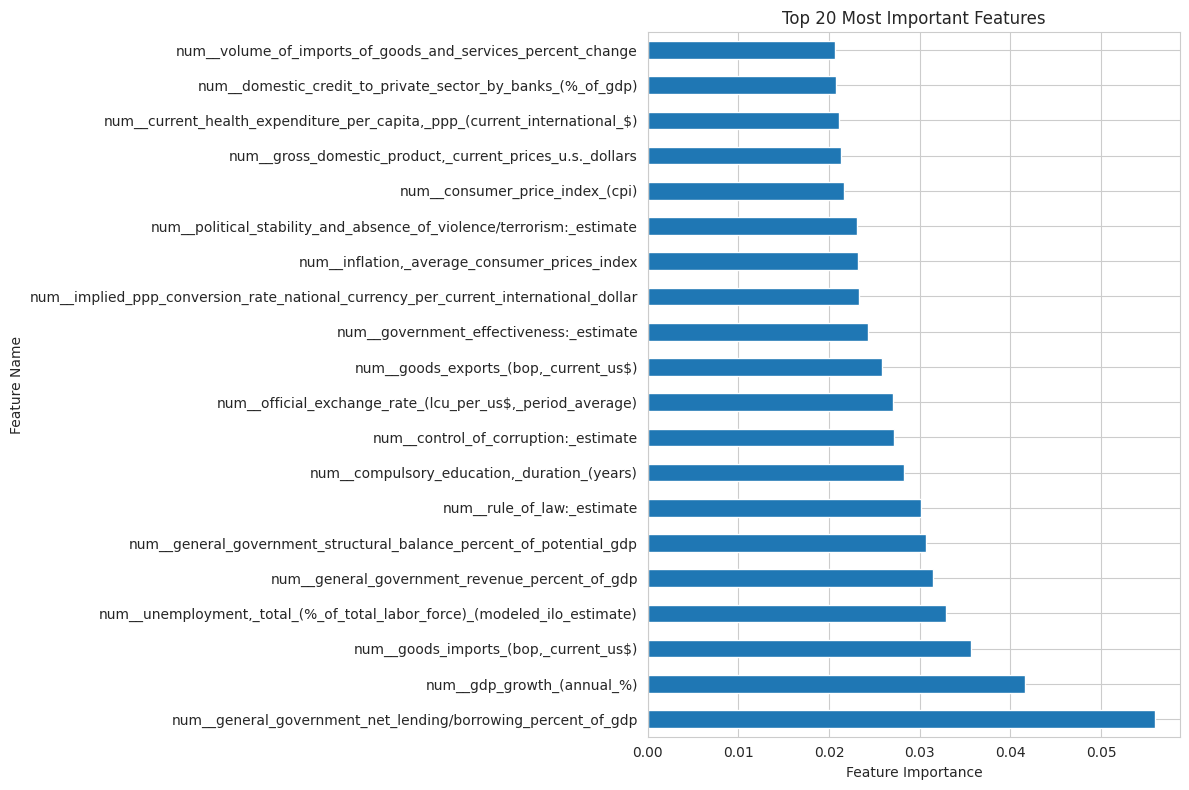

Multiclass Model Results


,train score,test score,accuracy,recall,precision,f1_score,average fit time
model,,,,,,,
randomforest,100.00%,76.91%,76.91%,65.92%,61.43%,63.10%,5.97s
xgboost,100.00%,78.36%,78.36%,61.26%,62.68%,61.94%,6.24s
histgradientboosting,98.64%,77.64%,77.64%,61.31%,61.53%,61.34%,2.16s
extratrees,77.61%,64.36%,64.36%,67.49%,53.48%,54.88%,2.13s
lightgbm,95.39%,75.45%,75.45%,63.05%,58.94%,60.65%,23.59s


Overall Best Model and Parameters
Best Model: xgboost
Best Test Score: 78.36%
Best Parameters: {'xgboost__subsample': 0.6, 'xgboost__n_estimators': 200, 'xgboost__min_child_weight': 2, 'xgboost__max_depth': 25, 'xgboost__learning_rate': 0.1, 'xgboost__colsample_bytree': 1}


In [57]:
def get_processed_feature_names(preprocessor):
    """
    This function gets the feature names after preprocessing.
    """
    return preprocessor.get_feature_names_out()

# This line should be called after a pipeline with the preprocessor has been fit
# processed_feature_names = get_processed_feature_names(preprocessor_fitted)

# Defining the models and hyperparameters
best_overall_model_yo = None
best_overall_score_yo = 0.0
best_overall_params_yo = {}
best_model_for_final_eval_yo = None

models = {
    'randomforest': (RandomForestClassifier(class_weight='balanced', random_state=42),
                     {'randomforest__n_estimators': [200, 300,],
                      'randomforest__max_depth': [10, 15, 30],
                      'randomforest__min_samples_leaf': [1, 5, 10, 15],
                      'randomforest__min_samples_split': [2, 5, 10, 15]
                     }),
    
    'xgboost': (XGBClassifier(objective="multi:softprob", random_state=42, num_class=3),
               {'xgboost__n_estimators': [100, 200, 300],
                'xgboost__learning_rate': [0.01, 0.05, 0.1],
                'xgboost__max_depth': [25, 50],
                'xgboost__min_child_weight':[2, 4, 6],
                'xgboost__subsample': [0.6, 0.4],
                'xgboost__colsample_bytree': [0.8, 1]
               }),

    'histgradientboosting': (HistGradientBoostingClassifier(random_state=42),
                             {'histgradientboosting__max_iter': [100, 200, 300],
                              'histgradientboosting__learning_rate': [0.01, 0.1, 0.2],
                              'histgradientboosting__max_leaf_nodes': [5, 15, 31]
                             }),

    'extratrees': (ExtraTreesClassifier(class_weight='balanced', random_state=42),
                   {'extratrees__n_estimators': [100, 200, 300, 500],
                    'extratrees__max_depth': [7, 10, 30],
                    'extratrees__min_samples_leaf': [1, 5, 10],
                    'extratrees__min_samples_split': [2, 5, 10]
                   }),
    
    'lightgbm': (LGBMClassifier(random_state=42, verbose=-1),
                {'lightgbm__n_estimators': [100, 200],
                 'lightgbm__num_leaves': [ 5, 10, 15],
                 'lightgbm__learning_rate': [0.01, 0.1],
                 'lightgbm__max_depth': [6, 8, 30],
                 'lightgbm__min_child_samples': [10, 15]
                }),
}

results = []
yo_pred_probas = {}

# Wrap the loop iterable with tqdm()
for name, (model, params) in tqdm(models.items(), desc="Training Models"):
    # --- Creating the pipeline ---
    pipeline = Pipeline([
        ('preprocessor', preprocessor_Xo),
        ('smote', ADASYN(random_state=42, n_neighbors=3)),
        (name, model)
    ])

    # I will select the best model based on F1-score
    f1_scorer = make_scorer(f1_score, average='macro')
    #grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring=f1_scorer)
    
    grid_search = RandomizedSearchCV(
        pipeline,
        param_distributions=params,
        n_iter=20, 
        cv=5,
        n_jobs=-1,
        scoring=f1_scorer,
        random_state=42
    )
    
    print(f"Training {name.upper()} on the full data.")
    start_time = time.time()
    
    grid_search.fit(Xo_train, yo_train)

    # Calculate the total duration for the entire grid search
    total_duration = time.time() - start_time
    fit_time = total_duration / len(grid_search.cv_results_['mean_fit_time'])
    
    best_model = grid_search.best_estimator_
    
    # --- Evaluate on preprocessed data ---
    train_score_yo = best_model.score(Xo_train, yo_train)
    test_score_yo = best_model.score(Xo_test, yo_test)
    
    if test_score_yo > best_overall_score_yo:
        best_overall_score_yo = test_score_yo
        best_overall_model_yo = name
        best_overall_params_yo = grid_search.best_params_
        best_model_for_final_eval_yo = best_model

    yo_pred = best_model.predict(Xo_test)
    
    # Calculate probabilities
    yo_pred_proba = best_model.predict_proba(Xo_test)
    
    # Store probabilities
    # For multiclass, ROC curve plotting needs to be handled differently (one-vs-rest)
    yo_pred_probas[name] = yo_pred_proba

    # Calculating metrics using the current predictions
    accuracy = accuracy_score(yo_test, yo_pred)
    recall = recall_score(yo_test, yo_pred, average='macro', zero_division=0)
    precision = precision_score(yo_test, yo_pred, average='macro', zero_division=0)
    f1 = f1_score(yo_test, yo_pred, average='macro', zero_division=0)

    # --- Metrics for the results DataFrame ---
    results.append([name, train_score_yo, test_score_yo, accuracy, recall, precision, f1, fit_time])

preprocessor_fitted_Xo = best_model_for_final_eval_yo.named_steps['preprocessor']
processed_feature_names_outlook = get_processed_feature_names(preprocessor_fitted_Xo)

# Access the best model from the fitted pipeline
best_classifier_outlook = best_model_for_final_eval_yo.named_steps[best_overall_model_yo]

# Check if the best classifier has the `feature_importances_` attribute
if hasattr(best_classifier_outlook, 'feature_importances_'):
    importances_outlook = best_classifier_outlook.feature_importances_

    # Create a pandas Series to easily view the importances with their corresponding names
    feature_importances_outlook_df = pd.Series(importances_outlook, index=processed_feature_names_outlook)

    # Sort the features by importance in descending order
    feature_importances_outlook_df = feature_importances_outlook_df.sort_values(ascending=False)

    # Print the top N most important features
    print("="*90)
    print("Feature Importances of the Best Model")
    print("="*90)
    print(feature_importances_outlook_df.head(20))

    # Visualize the feature importances with a bar chart
    plt.figure(figsize=(12, 8))
    feature_importances_outlook_df.head(20).plot(kind='barh')
    plt.title("Top 20 Most Important Features")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.tight_layout()
    plt.show()

else:
    print("The best model does not have a 'feature_importances_' attribute.")
    print("This method is only applicable to tree-based models like RandomForest, XGBoost, and LightGBM.")

# Creating the results DataFrame
results_outlook_df = pd.DataFrame(results, columns=['model', 'train score', 'test score', 'accuracy', 'recall', 'precision', 'f1_score', 'average fit time'])
results_outlook_df.set_index('model', inplace=True)

# Saving the df for the final analysis
results_df_yo = results_outlook_df

print("="*90)
print("Multiclass Model Results")
print("="*90)

# Beautifying the DataFrame
styled_df_yo = (results_df_yo.style
    .background_gradient(cmap='Blues')
    .format({
        'train score': '{:.2%}',
        'test score': '{:.2%}',
        'accuracy': '{:.2%}',
        'recall': '{:.2%}',
        'precision': '{:.2%}',
        'f1_score': '{:.2%}',
        'average fit time': '{:.2f}s',
        'total duration': '{:.2f}s'
    })
    .highlight_max(subset=['test score', 'accuracy', 'recall', 'precision', 'f1_score'], axis=0, color='green')
    .set_caption("Model Performance Metrics")
)

display(styled_df_yo)

print("="*90)
print("Overall Best Model and Parameters")
print("="*90)
print(f"Best Model: {best_overall_model_yo}")
print(f"Best Test Score: {best_overall_score_yo:.2%}")
print(f"Best Parameters: {best_overall_params_yo}")
print("="*90)

## 5. Evaluation

### 5.1 Country Rating results evaluation

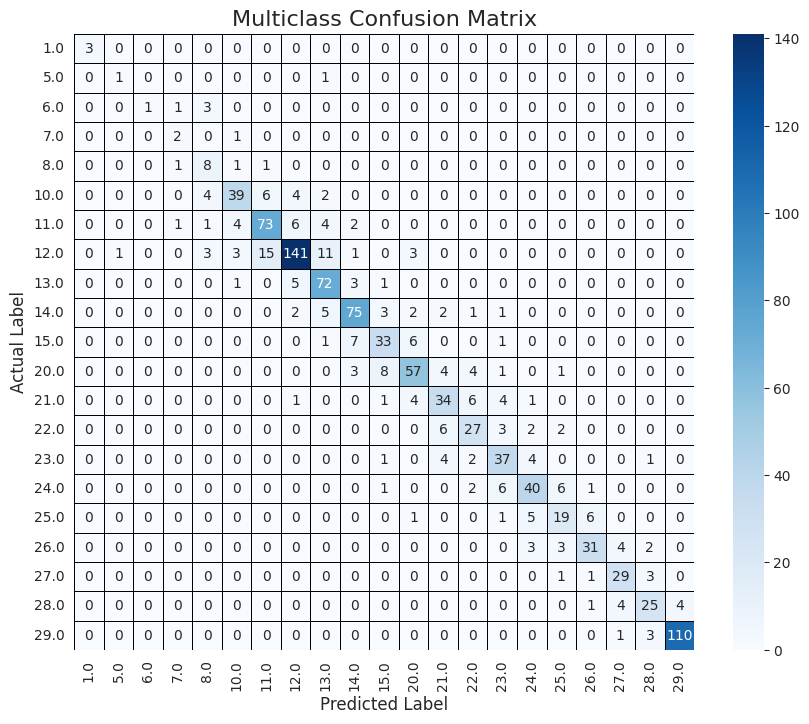

,precision,recall,f1-score,support
0,100.00%,100.00%,100.00%,3
1,50.00%,50.00%,50.00%,2
2,100.00%,20.00%,33.33%,5
3,40.00%,66.67%,50.00%,3
4,42.11%,72.73%,53.33%,11
5,79.59%,70.91%,75.00%,55
6,76.84%,80.22%,78.49%,91
7,88.68%,79.21%,83.68%,178
8,75.00%,87.80%,80.90%,82
9,82.42%,82.42%,82.42%,91


In [58]:
# Step 1: Get predictions from the best model
yr_pred_best = best_model_for_final_eval_yr.predict(Xr_test)

# Step 2: Create the multiclass confusion matrix
cm_yr = confusion_matrix(yr_test, yr_pred_best)

# Gt the class labels for the DataFrame
class_labels = le_yr.classes_

# Create a DataFrame for the confusion matrix with proper labels
cm_yr_df = pd.DataFrame(cm_yr, index=class_labels, columns=class_labels)

# Step 3: Create a heatmap for visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm_yr_df, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=0.5, linecolor='black')
plt.title('Multiclass Confusion Matrix', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# Step 4: Get and display the classification report
report_dict = classification_report(yr_test, yr_pred_best, output_dict=True, zero_division=0)
report_yr_df = pd.DataFrame(report_dict).transpose()

# Format and display the styled DataFrame
styled_report_yr = (report_yr_df.style
    .format({'precision': '{:.2%}',
             'recall': '{:.2%}',
             'f1-score': '{:.2%}',
             'support': '{:.0f}'})
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .set_caption("Classification Report")
)

print("="*100)

display(styled_report_yr)

In [59]:
# Build ROC AUC curve for yr

# Binarize labels for ROC curve
classes = np.unique(yr_test)
n_classes = len(classes)

# Ensure yr_test is binarized
yr_test_binarized = label_binarize(yr_test, classes=classes)

# Choose the best model's predicted probabilities
yr_score = yr_pred_probas[best_overall_model_yr]

# Compute ROC AUC (macro average)
roc_auc = roc_auc_score(yr_test_binarized, yr_score, average='macro', multi_class='ovr')

print("="*50)
print(f"Multiclass ROC AUC Score (macro average): {roc_auc:.4f}")
print("="*50)

Multiclass ROC AUC Score (macro average): 0.9768


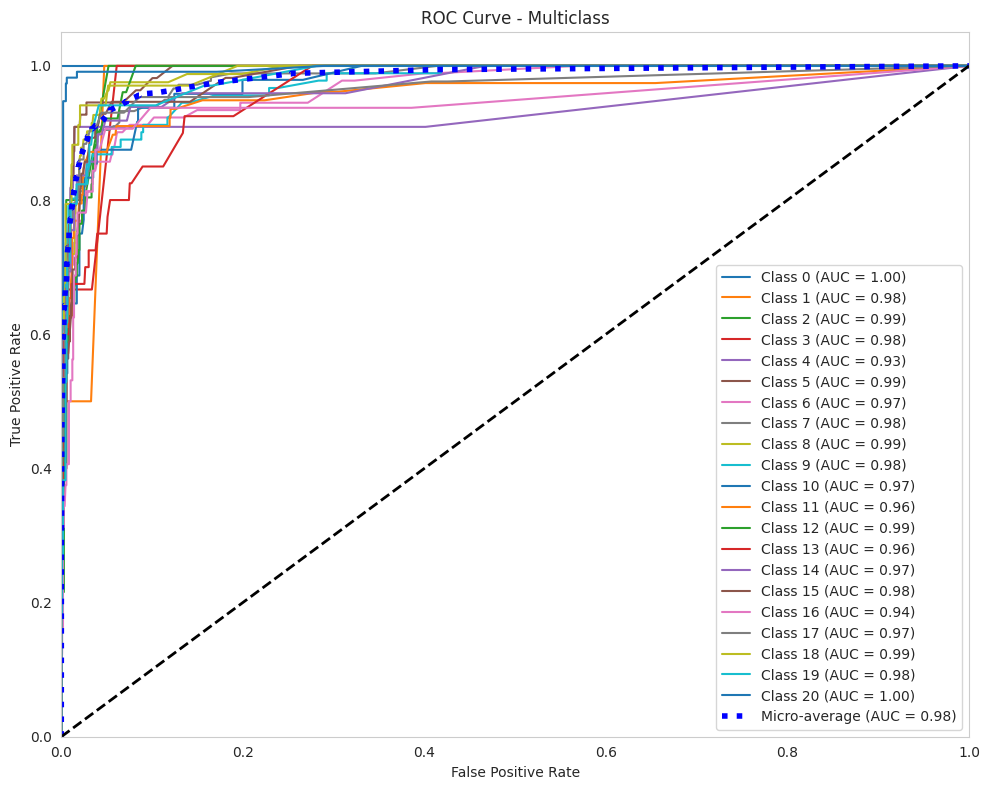

In [60]:
# 1. Initialize dictionaries to store results
fpr = dict()
tpr = dict()
roc_auc = dict()

# 2. Compute ROC curve and ROC area for EACH class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(yr_test_binarized[:, i], yr_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(yr_test_binarized.ravel(), yr_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# 4. Plot ROC curves
plt.figure(figsize=(10, 8))

# Plot each class's curve
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Plot the micro-average curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='blue', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multiclass')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

### 5.2 Country Outlook results evaluation

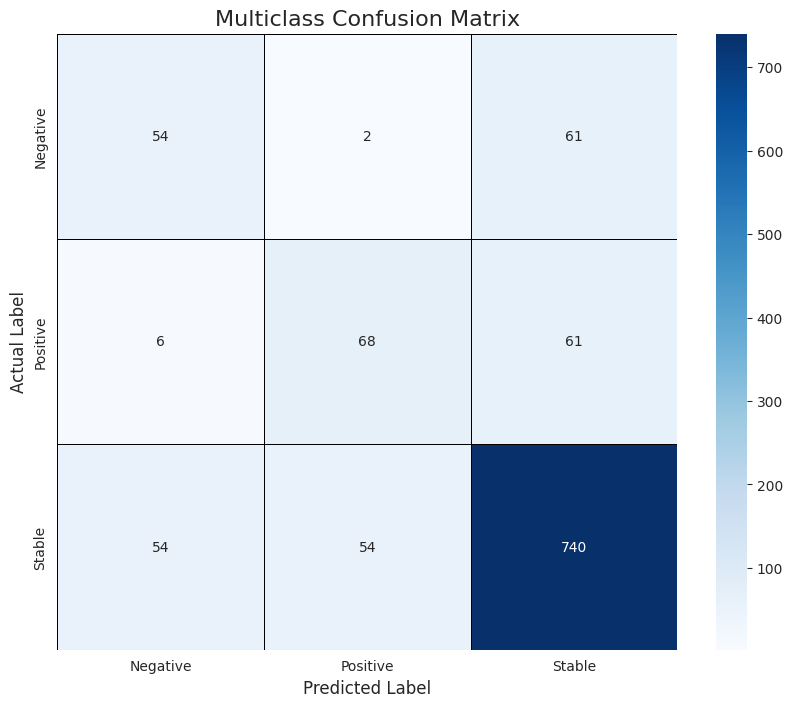

,precision,recall,f1-score,support
0,47.37%,46.15%,46.75%,117
1,54.84%,50.37%,52.51%,135
2,85.85%,87.26%,86.55%,848
accuracy,78.36%,78.36%,78.36%,1
macro avg,62.68%,61.26%,61.94%,1100
weighted avg,77.95%,78.36%,78.14%,1100


In [61]:
# Step 1: Get predictions from the best model
yo_pred_best = best_model_for_final_eval_yo.predict(Xo_test)

# Step 2: Create the multiclass confusion matrix
cm_yo = confusion_matrix(yo_test, yo_pred_best)

# Get the class labels for the DataFrame
class_labels = le_yo.classes_

# Create a DataFrame for the confusion matrix with proper labels
cm_yo_df = pd.DataFrame(cm_yo, index=class_labels, columns=class_labels)

# Step 3: Create a heatmap for visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm_yo_df, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=0.5, linecolor='black')
plt.title('Multiclass Confusion Matrix', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# Step 4: Get and display the classification report
report_dict = classification_report(yo_test, yo_pred_best, output_dict=True, zero_division=0)
report_yo_df = pd.DataFrame(report_dict).transpose()

# Format and display the styled DataFrame
styled_report_yo = (report_yo_df.style
    .format({'precision': '{:.2%}',
             'recall': '{:.2%}',
             'f1-score': '{:.2%}',
             'support': '{:.0f}'})
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .set_caption("Classification Report")
)

print("="*100)

display(styled_report_yo)

In [62]:
# Build ROC AUC curve for yo

# Binarize labels for ROC curve
classes = np.unique(yo_test)
n_classes = len(classes)

# Ensure yo_test is binarized
yo_test_binarized = label_binarize(yo_test, classes=classes)

# Choose the best model's predicted probabilities
yo_score = yo_pred_probas[best_overall_model_yo]

# Compute ROC AUC (macro average)
roc_auc = roc_auc_score(yo_test_binarized, yo_score, average='macro', multi_class='ovr')

print("="*50)
print(f"Multiclass ROC AUC Score (macro average): {roc_auc:.4f}")
print("="*50)

Multiclass ROC AUC Score (macro average): 0.8633


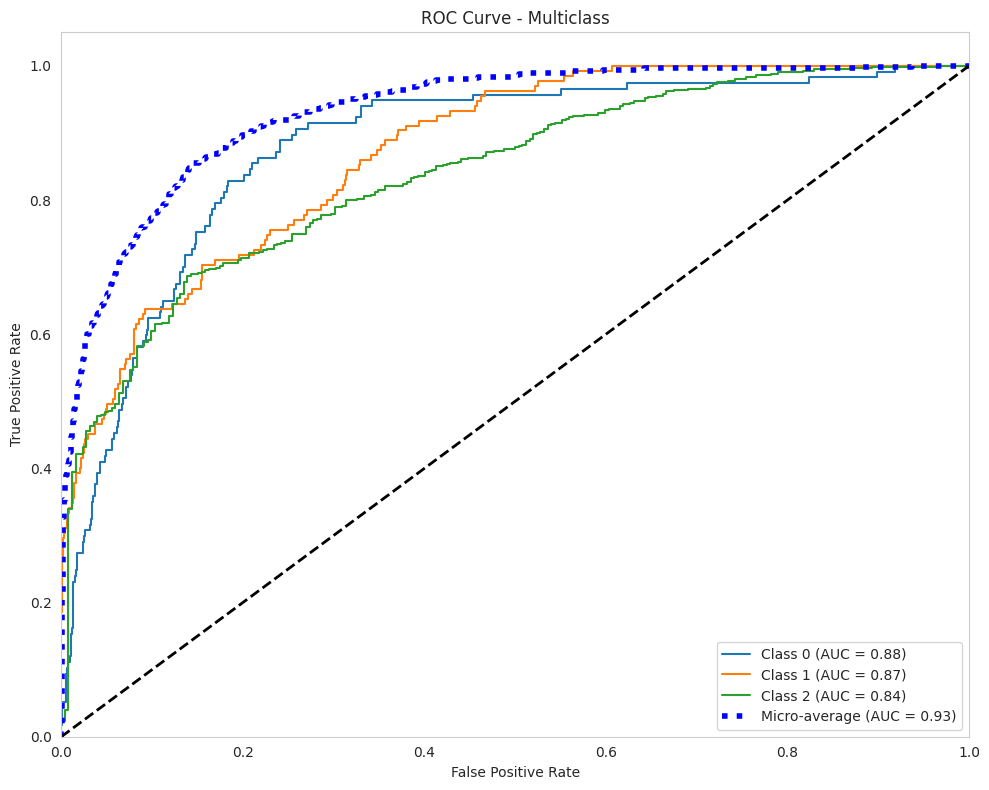

In [63]:
# 1. Initialize dictionaries to store results
fpr = dict()
tpr = dict()
roc_auc = dict()

# 2. Compute ROC curve and ROC area for EACH class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(yo_test_binarized[:, i], yo_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(yo_test_binarized.ravel(), yo_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# 4. Plot ROC curves
plt.figure(figsize=(10, 8))

# Plot each class's curve
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Plot the micro-average curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='blue', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multiclass')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

In [64]:
notebook_end_time = time.time()
notebook_elapsed_time = notebook_end_time - notebook_start_time
print("="*40)
print(f"Total Elapsed time : {notebook_elapsed_time/60:.2f} Minutes")
print("="*40)

Total Elapsed time : 94.18 Minutes


## 6. Deployment

In [65]:
# Inverse transform the LabelEncoder to get back to the ratingn values
yr_pred_best_ratingn = le_yr.inverse_transform(yr_pred_best)
print(yr_pred_best_ratingn)

[12. 14. 27. ... 23. 29. 14.]


In [66]:
# Inverse transform the LabelEncoder to get back to the outlook values
yo_pred_best_outlook = le_yo.inverse_transform(yo_pred_best)
print(yo_pred_best_outlook)

['Stable' 'Stable' 'Stable' ... 'Stable' 'Stable' 'Stable']


## 7. Next Steps for improvement 